# Model for Simulating Energy and Economic Performance of Power Stations in DR Aggregations V5.0

Includes variables for control type and if the PV system is plug-in or not.

To do:
* make sure plug-in version baseline isn't being negated on non-event days!
* discharge maximum

## Structure of the notebook

1) globals define
2) hardware and system characteristics define from data sets
3) energy modeling
   * PV modeling
   * battery modeling
4) financial modeling
5) DR performance modeling
6) big loop
7) basic results analysis


In [1]:
import pandas as pd
import numpy as np
import requests
import pvlib
import matplotlib.pyplot as plt  # for visualization
import math
from datetime import datetime
from statistics import median
from statistics import mean
from keys import *
from typing import List, Dict, Any
from collections import deque

In [2]:
#GLOBALS
#note that these coordinates are the inputs for the NREL API,
#the coordinates used by the NREL API for the weather file are slightly different
#see below
lat = 40.7128
long = -74.0060

#optimize for summer when DR program is in effect
#also minimizes shading from buildings during PSH
tilt = lat #math.floor(lat - 15)
print("tilt: " + str(tilt))

#default to south facing
azimuth = 180

#14% losses
shading = .86

#max 99% efficient mppt battery charger - used for PV to battery
mppt = .99

# conversion rate when charging battery from grid - used for grid to battery
acToDC = .95

# microinverter conversion efficiency is 95% - used for PV to grid
miEff = 0.95

# max 80% depth of discharge for LiFePO4 batteries under normal circumstances
# & 95% to maximize flexibiltiy during events
LiFePOdod = 0.80
LiFePOdod_event = 0.95

#Max Hardware Sizes
pvMaxW = 1200

#PV degredation rate is assumed to be 1% annually
DEG_RATE = 0.01

#days in the months May - September
daysInMonth = [31,30,31,31,30]
drSeasonStartDay = 121

# self consumption of both controller and power station
controllerSC = 1 #Raspberry Pi Zero 2W controller self-consumption
powerStationSC = 10.5 #power station no-load self-consumption with AC outputs turned on
scWDC = controllerSC + powerStationSC
dailySelfConsumptionWhDC = scWDC * 24
annualSelfConsumptionkWhDC = scWDC * 24 * 365 * 0.001


tilt: 40.7128


## Commercially Available Power Station Data


In [3]:
hardware_df = pd.read_csv('data/PowerStations_LiFePo4_June29_2026.csv')

#clean data - these columns aren't used in this analysis
hardware_df = hardware_df.drop(columns=['Link','Min PV Voltage','Max PV Voltage','Warranty Years','Lifespan','Notes','Estimated Full Charge Time','Estimated Minimum Grid Charge Efficiency'])

retailPriceColumns = ['Retail Price (3/14/2026)']

#filter out batteries over specified size
#print(hardware_df[hardware_df['Battery Wh'] > 2000])
#hardware_df = hardware_df[hardware_df['Battery Wh'] <= 2000]



In [4]:
pC = []
for c in hardware_df.columns:
    if 'Price (' in c:
        pC.append(c)

#get average retail prices
hardware_df['retail price']= hardware_df[retailPriceColumns].mean(axis=1)
hardware_df = hardware_df.drop(columns=pC) #drop raw price data

hardware_df = hardware_df.dropna(subset=['retail price']) #drop rows with missing avg prices

hardware_df.head()

,Make,Model,Battery Wh,Max PV Watts,Max PV Amps,Inverter Watts,Max AC Input Watts,Full Grid Charge Hours,80 Per Grid Charge Hours,Inverter Efficiency,Cycles,DoD,Passthrough,community API,official API,potential API,retail price
0,Jackery,Explorer 300 Plus,288.00,100,5.0,300.0,100.0,2.00,NaN,85.0,3000,80,True,True,False,False,299.0
1,Jackery,Explorer 600 Plus,632.00,200,10.5,800.0,1800.0,1.60,NaN,85.0,4000,70,True,True,False,False,429.0
2,Jackery,Explorer 700 Plus,680.96,600,11.0,1000.0,NaN,1.75,NaN,85.0,4000,70,NaN,True,False,False,599.0
3,Jackery,Explorer 1000 Plus,1264.64,800,22.0,2000.0,NaN,1.70,NaN,85.0,4000,70,NaN,True,False,False,599.0
4,Jackery,Explorer 2000 Plus,2042.80,1400,24.0,3000.0,NaN,2.00,NaN,85.0,4000,70,NaN,True,False,False,1099.0


In [5]:
hardware_df = hardware_df[(hardware_df['official API']==True)| (hardware_df['community API']==True)]

In [6]:
#display(hardware_df.tail())

#get average charge time percent for 80% relative to a 100% charge
hardware_df['charge ratio']= hardware_df['80 Per Grid Charge Hours']/hardware_df['Full Grid Charge Hours']

#display(hardware_df[~hardware_df['charge ratio'].isnull()]['charge ratio'])
#get the average ratio of 80% to 100% 
eightyCT = round(hardware_df[~hardware_df['charge ratio'].isnull()]['charge ratio'].mean()*100,2)*.01
print(str(eightyCT*100) + '% of the full charge time is spent charging from 0-80%.')
# #display(hardware_df.tail())

#update full charge column
hardware_df['Full Grid Charge Hours'].loc[hardware_df['Full Grid Charge Hours'].isnull()] = hardware_df['80 Per Grid Charge Hours'].loc[hardware_df['Full Grid Charge Hours'].isnull()] / eightyCT

#update 80% charge column
hardware_df['80 Per Grid Charge Hours'].loc[hardware_df['80 Per Grid Charge Hours'].isnull()] = hardware_df['Full Grid Charge Hours'].loc[hardware_df['80 Per Grid Charge Hours'].isnull()] * eightyCT

63.99% of the full charge time is spent charging from 0-80%.


C:\Users\alexn\AppData\Local\Temp\ipykernel_30752\995307535.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  hardware_df['Full Grid Charge Hours'].loc[hardware_df['Full Grid Charge Hours'].isnull()] = hardware_df['80 Per Grid Charge Hour

In [7]:
tP = hardware_df.shape[0]

inverterEfficiencyMean = round(hardware_df['Inverter Efficiency'].mean(),4)
invEffDefault = inverterEfficiencyMean * 0.01
print('Default Efficiency for use in model: ' + str(inverterEfficiencyMean))
print('% with unknown efficiency: ' + str(100*hardware_df[hardware_df['Inverter Efficiency'].isnull()].shape[0]/tP))
hardware_df['Inverter Efficiency'] = hardware_df['Inverter Efficiency'].fillna(inverterEfficiencyMean)
hardware_df['Inverter Efficiency'] = hardware_df['Inverter Efficiency']*.01


Default Efficiency for use in model: 86.6667
% with unknown efficiency: 0.0


In [8]:
# price per Wh
hardware_df['$/Wh'] = hardware_df['retail price']/hardware_df['Battery Wh']

In [9]:
hardware_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45 entries, 0 to 53
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Make                      45 non-null     object 
 1   Model                     45 non-null     object 
 2   Battery Wh                45 non-null     float64
 3   Max PV Watts              45 non-null     int64  
 4   Max PV Amps               29 non-null     float64
 5   Inverter Watts            44 non-null     float64
 6   Max AC Input Watts        37 non-null     float64
 7   Full Grid Charge Hours    45 non-null     float64
 8   80 Per Grid Charge Hours  45 non-null     float64
 9   Inverter Efficiency       45 non-null     float64
 10  Cycles                    45 non-null     int64  
 11  DoD                       45 non-null     int64  
 12  Passthrough               2 non-null      object 
 13  community API             45 non-null     bool   
 14  official API     

In [10]:
hardware_df.describe()

,Battery Wh,Max PV Watts,Max PV Amps,Inverter Watts,Max AC Input Watts,Full Grid Charge Hours,80 Per Grid Charge Hours,Inverter Efficiency,Cycles,DoD,retail price,charge ratio,$/Wh
count,45.000000,45.000000,29.000000,44.000000,37.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,4.000000,45.000000
mean,1165.564444,610.666667,13.610345,1475.000000,1128.324324,1.581524,1.011585,0.866667,3511.111111,78.888889,562.800000,0.639881,0.576610
std,751.915725,479.779305,6.417017,864.580823,659.223873,0.696704,0.446749,0.035355,678.307460,3.178209,305.745408,0.103954,0.257100
min,204.000000,100.000000,5.000000,300.000000,100.000000,0.820441,0.525000,0.800000,2500.000000,70.000000,149.000000,0.500000,0.305339
25%,512.000000,200.000000,8.200000,600.000000,500.000000,1.170000,0.750000,0.850000,3000.000000,80.000000,300.000000,0.607143,0.389757
50%,1024.000000,500.000000,12.000000,1500.000000,1200.000000,1.500000,0.959850,0.850000,3500.000000,80.000000,549.000000,0.654762,0.493490
75%,2000.000000,1000.000000,20.000000,2200.000000,1800.000000,1.800000,1.151820,0.900000,4000.000000,80.000000,799.000000,0.687500,0.682617
max,3072.000000,2400.000000,25.000000,3600.000000,2400.000000,4.500000,2.879550,0.900000,6000.000000,80.000000,1499.000000,0.750000,1.486352


In [11]:
# data snapshot
print('Total Number of Companies: ' + str(hardware_df.drop_duplicates(subset=['Make']).shape[0]))
print('Total Number of Products: ' + str(tP))

print('')
print('*** PV Charge Time (without losses) ***')
print('Min:' + str(min(hardware_df['Battery Wh']/(hardware_df['Max PV Watts']*.99))))
print('Max:' + str(max(hardware_df['Battery Wh']/(hardware_df['Max PV Watts']*.99))))
pvChargeMed = (hardware_df['Battery Wh']/(hardware_df['Max PV Watts']*.99)).median()
print('Median:' + str(pvChargeMed))

Total Number of Companies: 6
Total Number of Products: 45

*** PV Charge Time (without losses) ***
Min:0.8619528619528619
Max:5.818181818181818
Median:2.0686868686868687


## Con Ed Network Data

In [12]:
# read in hardware data to dataframe
networks_df = pd.read_csv('data/conEdNetworks2026.csv')

networksToSim = ['bowling green','borden','sunnyside','grasslands','fresh kills','central bronx','fordham','park slope']
networks_df[networks_df['network'].isin(networksToSim)]

,borough,network,start time,end time,tier
0,bronx,central bronx,19:00,23:00,2
1,bronx,fordham,16:00,20:00,2
12,brooklyn,park slope,14:00,18:00,2
19,manhattan,bowling green,11:00,15:00,1
56,queens,borden,14:00,18:00,1
64,queens,sunnyside,16:00,20:00,1
66,staten island,fresh kills,19:00,23:00,1
74,westchester,grasslands,16:00,20:00,1


In [13]:
#returns the network info for a given network
#args: network name
def getNetworkInfo(networkName):
    return networks_df.loc[networks_df['network']== networkName]

#returns the tier for a given item in the network info list
#args: network name
def getDLRPrate(networkName):
    n = getNetworkInfo(networkName)
    t = n['tier'].iloc[0]
    #tier 2 networks pay at a higher rate
    if t == 1:
        return 18
    else:
        return 25
    
#returns the borough for a given item in the network info list
#args: network name
def getCSRPrate(networkName):
    n = getNetworkInfo(networkName)
    t = n['borough'].iloc[0]
    #westchester and staten island pay at a lower rate
    if t not in ['westchester','staten island']:
        return 18
    else:
        return 6

#args: network name
def getTotalRate(networkName):
    return getDLRPrate(networkName) + getCSRPrate(networkName)
    
#returns borough name
#args: network name
def getBorough(networkName):
    n = getNetworkInfo(networkName)
    return n['borough'].iloc[0]

#returns event start time
#args: network name
def getStartTime(networkName):
    n = getNetworkInfo(networkName)
    return int(n['start time'].iloc[0].split(":")[0])

## PV Performance Modeling

In [14]:
#get TMY via API
try:
    df_tmy, metadata = pvlib.iotools.get_nsrdb_psm4_tmy(
        latitude=lat,
        longitude=long,
        api_key=NREL_API_KEY,
        time_step=60,
        email='nathaa@rpi.edu',  # <-- any email works here fine
        year='tmy-2024')
except requests.HTTPError as e:
    print("Status code:", e.response.status_code)
    print("Raw response text:")
    print(e.response.text)
    raise

metadata

{'Source': 'NSRDB',
 'Location ID': '1243965',
 'City': '-',
 'State': '-',
 'Country': '-',
 'Time Zone': -5,
 'Local Time Zone': -5,
 'Clearsky DHI Units': 'w/m2',
 'Clearsky DNI Units': 'w/m2',
 'Clearsky GHI Units': 'w/m2',
 'Dew Point Units': 'c',
 'DHI Units': 'w/m2',
 'DNI Units': 'w/m2',
 'GHI Units': 'w/m2',
 'Solar Zenith Angle Units': 'Degree',
 'Temperature Units': 'c',
 'Pressure Units': 'mbar',
 'Relative Humidity Units': '%',
 'Precipitable Water Units': 'cm',
 'Wind Direction Units': 'Degrees',
 'Wind Speed Units': 'm/s',
 'Cloud Type -15': 'N/A',
 'Cloud Type 0': 'Clear',
 'Cloud Type 1': 'Probably Clear',
 'Cloud Type 2': 'Fog',
 'Cloud Type 3': 'Water',
 'Cloud Type 4': 'Super-Cooled Water',
 'Cloud Type 5': 'Mixed',
 'Cloud Type 6': 'Opaque Ice',
 'Cloud Type 7': 'Cirrus',
 'Cloud Type 8': 'Overlapping',
 'Cloud Type 9': 'Overshooting',
 'Cloud Type 10': 'Unknown',
 'Cloud Type 11': 'Dust',
 'Cloud Type 12': 'Smoke',
 'Fill Flag 0': 'N/A',
 'Fill Flag 1': 'Missing I

In [15]:
df_tmy.to_csv("data/tmy_2024_NYC.csv", index=True)

In [16]:
# make a Location object corresponding to this TMY
location = pvlib.location.Location(name='NYC',
                                   latitude=metadata['latitude'],
                                   longitude=metadata['longitude'])

location

Location: 
  name: NYC
  latitude: 40.73
  longitude: -74.02
  altitude: -2.0
  tz: UTC

In [17]:
#normalize all years to 2020
#remove timezone info #,tzinfo=None
df_tmy.index = df_tmy.index.map(lambda t: t.replace(year=2020))

#uncomment the 30 minute shifts if using data that is right-labeled at hourly intervals!
# Note: TMY datasets are right-labeled hourly intervals, e.g. the
# 10AM to 11AM interval is labeled 11.  We should calculate solar position in
# the middle of the interval (10:30), so we subtract 30 minutes:
times = df_tmy.index #- pd.Timedelta('30min')
solar_position = location.get_solarposition(times)
# but remember to shift the index back to line up with the TMY data:
#solar_position.index += pd.Timedelta('30min')

solar_position

,apparent_zenith,zenith,apparent_elevation,elevation,azimuth,equation_of_time
2020-01-01 00:30:00-05:00,161.167644,161.167644,-71.167644,-71.167644,22.397593,-3.190860
2020-01-01 01:30:00-05:00,154.001161,154.001161,-64.001161,-64.001161,54.029306,-3.210673
2020-01-01 02:30:00-05:00,143.834623,143.834623,-53.834623,-53.834623,72.365773,-3.230477
2020-01-01 03:30:00-05:00,132.705852,132.705852,-42.705852,-42.705852,84.714658,-3.250272
2020-01-01 04:30:00-05:00,121.355180,121.355180,-31.355180,-31.355180,94.580427,-3.270057
...,...,...,...,...,...,...
2020-12-31 19:30:00-05:00,121.549755,121.549755,-31.549755,-31.549755,265.621718,-3.441097
2020-12-31 20:30:00-05:00,132.896245,132.896245,-42.896245,-42.896245,275.528481,-3.460697
2020-12-31 21:30:00-05:00,144.009842,144.009842,-54.009842,-54.009842,287.965009,-3.480288
2020-12-31 22:30:00-05:00,154.134861,154.134861,-64.134861,-64.134861,306.489310,-3.499870


In [18]:
#get monthly temperature averages for validation
# for m in range(12):
#     df_tmy['Temperature']

In [19]:
# temperature coef
gamma_pdc = -0.003  # divide by 100 to go from %/°C to 1/°C

all_parameters = pvlib.temperature.TEMPERATURE_MODEL_PARAMETERS['sapm']
parameters = all_parameters['open_rack_glass_polymer']

#args: tilt, azimuth
def getPOA(t,a):
    #fixed tilt POA
    df_poa = pvlib.irradiance.get_total_irradiance(
        surface_tilt=t,
        surface_azimuth=a,
        dni=df_tmy['dni'],
        ghi=df_tmy['ghi'],
        dhi=df_tmy['dhi'],
        solar_zenith=solar_position['apparent_zenith'],
        solar_azimuth=solar_position['azimuth'],
        model='isotropic')

    #print(df_poa.keys())
    return df_poa

#DC power going in to battery after accounting for shading and equipment derating
#https://pvlib-python.readthedocs.io/en/stable/reference/generated/pvlib.pvsystem.pvwatts_dc.html#
#args: power, temp coefficient, array nameplate watts
def getPowerYield(p,g,n):
    
    # note the "splat" operator "**" which expands the dictionary "parameters"
    # into a comma separated list of keyword arguments
    cell_temperature = pvlib.temperature.sapm_cell(
        p['poa_global'], df_tmy['temp_air'], df_tmy['wind_speed'], **parameters)
    
    array_power = pd.DataFrame({
        'power': pvlib.pvsystem.pvwatts_dc(p['poa_global'], cell_temperature, n, g,temp_ref=25.0)
    })

    #yieldDC is actual power going in to battery after losses
    array_power['yieldDC'] = array_power['power'] * shading * mppt

    #yieldAC is actual power going in to grid after losses
    array_power['yieldAC'] = array_power['power'] * shading * miEff
    
    return array_power
    #array_power = pvlib.pvsystem.pvwatts_dc(df_poa['poa_global'], cell_temperature, n, g,temp_ref=25.0)

    #factor in 14% shading losses + 1% mppt losses
    #return array_power * shading * mppt

# #convert DC to AC with PV Watts model
# #https://pvlib-python.readthedocs.io/en/stable/reference/generated/pvlib.inverter.pvwatts.html#pvlib.inverter.pvwatts
# #args: dc power input to inverter, inverter nameplate max WAC output, nameplate efficiency


#returns the degraded power of the array for a given year
#args: PV watts, year, PV degradation rate
def getDegradedP(w,y,dR = DEG_RATE):
    d = 1 - dR
    return w*(d**y)

array_power_yield = getPowerYield(getPOA(tilt,azimuth),gamma_pdc, 100)
array_power_yield.head()

,power,yieldDC,yieldAC
2020-01-01 00:30:00-05:00,0.0,0.0,0.0
2020-01-01 01:30:00-05:00,0.0,0.0,0.0
2020-01-01 02:30:00-05:00,0.0,0.0,0.0
2020-01-01 03:30:00-05:00,0.0,0.0,0.0
2020-01-01 04:30:00-05:00,0.0,0.0,0.0


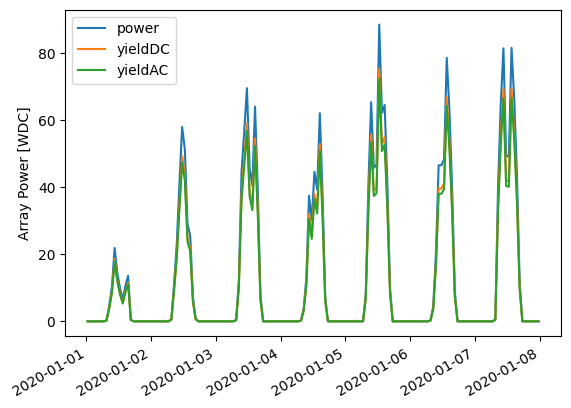

In [20]:
array_power_yield.head(24*7).plot()
plt.ylabel('Array Power [WDC]');

In [21]:
# this function gets yield data for a range of things
def getYieldData(tilt=tilt, gamma_pdc=gamma_pdc, maxPV=pvMaxW, pvInc=50, azimuths=(110, 180, 250)):
    """
    Get hourly and daily PV yields for all possible array sizes being modeled,
    at each of the given azimuths.

    Args:
        tilt (float): array tilt angle (degrees).
        gamma_pdc (float): PV temperature coefficient (1/°C).
        maxPV (int): max allowed PV nameplate wattage of any power station
                     in the database (default 1200).
        pvInc (int): increment (W) to step through array sizes (default 50).
        azimuths (iterable of int): azimuth angles to model (default (110, 180, 250)).

    Returns:
        dict: {
            '<azimuth>': {
                '<pW>': {
                    'hourly': <DataFrame from getPowerYield>,
                    'daily': {'dailyDC': [...], 'dailyAC': [...]}
                },
                ...
            },
            ...
        }
    """
    yieldData = {str(a): {} for a in azimuths}

    #print(f'Max PV: {maxPV}')

    for a in azimuths:
        poa = getPOA(tilt, a)

        aData = {}
        for pW in range(pvInc, maxPV + pvInc, pvInc):
            # get hourly power yields for a given array size (W)
            hY = getPowerYield(poa, gamma_pdc, pW)

            # get daily PV yields (Wh)
            # dYDC = []
            # dYAC = []
            # for d in range(365):
            #     dYDC.append(hY['yieldDC'].iloc[d*24:(d*24)+24].sum())
            #     dYAC.append(hY['yieldAC'].iloc[d*24:(d*24)+24].sum())
            dYDC = hY['yieldDC'].to_numpy().reshape(365, 24).sum(axis=1)
            dYAC = hY['yieldAC'].to_numpy().reshape(365, 24).sum(axis=1)

            aData[str(pW)] = {
                'hourly': hY,
                'daily': {'dailyDC': dYDC, 'dailyAC': dYAC}
            }

        yieldData[str(a)] = aData

    return yieldData
    

In [22]:
yieldData = getYieldData()

# Annual Energy Modeling

battery is only charged from the grid when an event is upcoming. This considers average solar in July

In [23]:
def pv_to_stored_charge(pv_w, plugin, acToDC):
    """Energy reaching the battery as stored charge, after conversion losses.
    plugin=True: pv_w is already AC (post-microinverter) -> battery charger (acToDC).
    plugin=False: pv_w is DC -> straight into battery, no conversion loss."""
    return pv_w * acToDC if plugin else pv_w

def battery_to_load(load_wac, iE):
    """AC load converted into the DC draw required from the battery
    (battery inverter, discharge side)."""
    return load_wac / iE

In [24]:
def simulate_hourly_energy(pvYieldW, batWh, loadWAC, iE, y: int = 0, plugin=True,
                            dailySelfConsumptionWhDC=dailySelfConsumptionWhDC,
                            LiFePOdod=LiFePOdod, acToDC=acToDC,
                            chargeTargetFraction=0.8, startState=0.5,
                            gridChargeRateW=1800, gridWindowStartHour=None):
    """
    Step through a year hour-by-hour, simulating a charge/discharge cycle
    capped at once per calendar day, with any grid-sourced charging capped
    at gridChargeRateW (Wh/hour) rather than applied instantly -- the
    number of hours it takes depends on how large the gap is.'

    loadWAC may be either a scalar (constant load every hour, the original
    behavior) or an array-like of length len(pvYieldW) giving an hourly
    load profile -- e.g. a load that's only "on" during certain months
    (see build_seasonal_load_array). Internally it's always expanded to a
    per-hour array so seasonal and constant loads are handled identically.

    OFF-GRID discharge triggers: either the battery reaches chargeTarget
    (80%) after 3pm on a day the cycle hasn't been used yet, OR projected
    overflow risk (reserving multi-hour headroom based on the trailing
    week's peak PV hour vs. load size) forces an early discharge to avoid
    curtailing PV, regardless of time or the daily cap. If discharge was
    triggered by overflow risk specifically, it reverts back to 'charging'
    as soon as that risk resolves (rather than waiting for the DoD floor),
    and frees the daily cycle back up so a normal 80%-target discharge can
    still happen later that day if conditions call for it.
    """
    
    seasonStartDay=drSeasonStartDay
    seasonDays=daysInMonth
    
    gridWindowLengthHours=4
    gridWindowEndHour = None
    if gridWindowStartHour is not None:
        gridWindowEndHour = gridWindowStartHour + gridWindowLengthHours

    # the grid window only applies during the DR season (e.g. May-Sep);
    # outside the season it behaves as if gridWindowStartHour were None
    seasonStartHour = (seasonStartDay - 1) * 24
    seasonEndHour = seasonStartHour + (sum(seasonDays) * 24)  # exclusive

    n = len(pvYieldW)

    # expand loadWAC to a per-hour array so scalar and seasonal/array loads
    # are handled by the exact same code path below
    loadWAC_arr = np.full(n, loadWAC, dtype=float) if np.isscalar(loadWAC) else np.asarray(loadWAC, dtype=float)
    if len(loadWAC_arr) != n:
        raise ValueError(f'loadWAC array length ({len(loadWAC_arr)}) must match pvYieldW length ({n})')
    loadWDC_arr = battery_to_load(loadWAC_arr, iE)

    dodFloor = batWh * (1 - LiFePOdod)
    chargeTarget = batWh * chargeTargetFraction
    hourlyScWDC = dailySelfConsumptionWhDC / 24

    #n = len(pvYieldW)
    batState_arr = np.empty(n)
    surplus_arr = np.zeros(n)
    avoided_arr = np.zeros(n)
    required_arr = np.zeros(n)
    grid_to_load_arr = np.zeros(n)
    grid_battery_charge_arr = np.zeros(n)

    batState = batWh * startState
    mode = 'charging'
    dischargeCycleUsedToday = False
    rechargeCycleUsedToday = False
    dischargingDueToOverflow = False   # off-grid: tracks whether the current discharge was overflow-triggered

    floorCharging = False
    rechargingFromGrid = False

    pvHistory = deque(maxlen=168)

    dischargeHour = 20 if gridWindowEndHour is None else gridWindowEndHour

    for i, h in enumerate(pvYieldW):
        hourOfDay = i % 24
        if hourOfDay == 0:
            dischargeCycleUsedToday = False
            rechargeCycleUsedToday = False

        pv_w = getDegradedP(h, y)
        loadWAC = loadWAC_arr[i]
        loadWDC = loadWDC_arr[i]
        
        # check if this hour is within the DR window
        inSeason = seasonStartHour <= i < seasonEndHour
        inGridWindow = (
            gridWindowEndHour is not None
            and inSeason
            and gridWindowStartHour <= hourOfDay < gridWindowEndHour
        )

        if not plugin:
            # ---------------- OFF-GRID ----------------
            stored = pv_w
            batState += stored - hourlyScWDC   # PV always charges simultaneously, regardless of mode
            pvHistory.append(stored)

            maxHourlyPVPastWeek = max(pvHistory) if pvHistory else stored
            denom = loadWDC if loadWDC > 0 else 1e-6
            reserve = min(maxHourlyPVPastWeek * (maxHourlyPVPastWeek / denom), batWh)
            wouldOverflow = (batState + reserve) > batWh
            hourOfDay = i % 24

            if mode == 'charging':
                reachedTarget = batState >= chargeTarget
                if wouldOverflow or (reachedTarget and not dischargeCycleUsedToday and hourOfDay >= dischargeHour):
                    mode = 'discharging'
                    dischargeCycleUsedToday = True
                    dischargingDueToOverflow = wouldOverflow
            elif mode == 'discharging':
                if dischargingDueToOverflow and not wouldOverflow:
                    mode = 'charging'
                    dischargeCycleUsedToday = False  # frees the cycle back up for a later 3pm+ discharge
                    dischargingDueToOverflow = False

            if mode == 'charging':
                avoided_arr[i] = 0.0
                grid_to_load_arr[i] = loadWAC
            # else:  # discharging
            #     availableWDC = max(0.0, batState - dodFloor)
            #     servedWDC = min(loadWDC, availableWDC)
            #     batState -= servedWDC
            #     avoided_arr[i] = servedWDC * iE
            #     grid_to_load_arr[i] = loadWAC - avoided_arr[i]
            else:  # discharging
                if inGridWindow:
                    # grid window: never discharge the battery to serve the
                    # load, even if a discharge cycle is already underway
                    if dischargingDueToOverflow:
                        # still avoid curtailing/wasting PV even during the window,
                        # but only pull the minimum needed to prevent overflow --
                        # never a full load-serving discharge
                        overflowAmount = max(0.0, batState - batWh)
                        availableWDC = max(0.0, batState - dodFloor)
                        servedWDC = min(overflowAmount, availableWDC, loadWDC)
                    else:
                        # grid window: never voluntarily discharge to serve the load
                        servedWDC = 0.0
                elif hourOfDay >= dischargeHour:
                    # after the set discharge time: draw as much as the load needs, normal cycling behavior
                    availableWDC = max(0.0, batState - dodFloor)
                    servedWDC = min(loadWDC, availableWDC)
                else:
                    # before the set discharge time: only pull what's needed to avoid exceeding capacity
                    overflowAmount = max(0.0, batState - batWh)
                    availableWDC = max(0.0, batState - dodFloor)
                    servedWDC = min(overflowAmount, availableWDC, loadWDC)
            
                batState -= servedWDC
                avoided_arr[i] = servedWDC * iE
                grid_to_load_arr[i] = loadWAC - avoided_arr[i]

            # DoD floor safety net, rate-capped instead of instant
            if batState < dodFloor:
                floorCharging = True
            if floorCharging:
                gap = dodFloor - batState
                chargeAmount = min(gap, gridChargeRateW)
                batState += chargeAmount
                required_arr[i] = chargeAmount / acToDC
                if batState >= dodFloor:
                    floorCharging = False

            # capacity safety net -- true curtailment, should be rare given the overflow check above
            if batState > batWh:
                sur = batState - batWh
                surplus_arr[i] = sur * iE
                batState = batWh

            # reaching the DoD floor always ends a discharge cycle, overflow-triggered or not
            if mode == 'discharging' and batState <= dodFloor:
                mode = 'charging'
                dischargingDueToOverflow = False

        else:
            # ---------------- PLUG-IN ----------------
            pv_avail_AC = pv_w  # already AC (microinverter output)

            if inGridWindow:
                # grid window: grid fully serves the load; any available PV
                # is redirected to charge the battery instead of the load
                avoided_arr[i] = 0.0
                grid_to_load_arr[i] = loadWAC

                pv_to_batt_DC = pv_to_stored_charge(pv_avail_AC, True, acToDC)
                room_DC = max(0.0, batWh - batState)
                chargeAmount_DC = min(pv_to_batt_DC, room_DC)
                batState += chargeAmount_DC
                grid_battery_charge_arr[i] = 0.0  # this charge comes from PV, not the grid
                # any PV that couldn't be stored is curtailed/exported
                storedAsPV_AC = chargeAmount_DC / acToDC if acToDC else 0.0
                surplus_arr[i] = max(0.0, pv_avail_AC - storedAsPV_AC)
            else:  
                servedByPV_AC = min(loadWAC, pv_avail_AC)
                avoided_arr[i] = servedByPV_AC  # PV directly serving load is genuinely avoided grid draw
                remainingLoad_AC = loadWAC - servedByPV_AC
                surplus = pv_avail_AC - servedByPV_AC
        
                canDischargeForLoad = hourOfDay >= dischargeHour
        
                if rechargingFromGrid:
                    gap = chargeTarget - batState
                    chargeAmount = min(gap, gridChargeRateW)
                    batState += chargeAmount
                    chargeAmtAC = chargeAmount / acToDC
                    usefulOutputAC = chargeAmount * iE
                    surplus_arr[i] = max(0, surplus - chargeAmtAC)
                    grid_battery_charge_arr[i] = chargeAmtAC
                    required_arr[i] = chargeAmtAC - usefulOutputAC
                    grid_to_load_arr[i] = remainingLoad_AC
                    if batState >= chargeTarget:
                        rechargingFromGrid = False
                else:
                    surplus_arr[i] = surplus
            
                    if canDischargeForLoad:
                        remainingLoadWDC = remainingLoad_AC / iE
                        availableWDC = max(0.0, batState - dodFloor)
                        servedWDC = min(remainingLoadWDC, availableWDC)
                        batState -= servedWDC
                        grid_to_load_arr[i] = remainingLoad_AC - (servedWDC * iE)
                    else:
                        # before 3pm: no battery discharge for load -- battery just self-depletes
                        # (self-consumption below); grid covers whatever PV didn't
                        grid_to_load_arr[i] = remainingLoad_AC
        
            batState -= hourlyScWDC
        
            if not rechargingFromGrid and batState < dodFloor:
                topOff = dodFloor - max(batState, 0)
                required_arr[i] += topOff / acToDC
                batState = dodFloor
        
            if batState <= dodFloor and not rechargeCycleUsedToday and not rechargingFromGrid:
                rechargingFromGrid = True
                rechargeCycleUsedToday = True

        batState_arr[i] = batState

    return {
        'batState': batState_arr,
        'surplusWhAC': surplus_arr,
        'avoidedGridWhAC': avoided_arr,
        'requiredGridWhAC': required_arr,
        'grid_to_loadWhAC': grid_to_load_arr,
        'gridBatteryChargeWhAC': grid_battery_charge_arr,
    }

def build_seasonal_load_array(loadW, seasonal=False, n_hours=None,
                               season_start_day=drSeasonStartDay,
                               season_days=daysInMonth):
    """
    Build an hourly load array for a full year (or n_hours, if given).

    seasonal=False: load is constant, on all year round (e.g. a fridge --
    always drawing power, so PV/battery should offset it every month).
    seasonal=True: load is only "on" during the DR season (by default May 1
    through Sep 30, i.e. day season_start_day through
    season_start_day + sum(season_days) - 1) and zero the rest of the year
    (e.g. an AC unit that isn't in use outside the DR season).

    Returns a numpy array of length n_hours (default 365*24 = 8760).
    """
    if n_hours is None:
        n_hours = 365 * 24

    if not seasonal:
        return np.full(n_hours, loadW, dtype=float)

    season_len_days = sum(season_days)
    season_start_hour = (season_start_day - 1) * 24
    season_end_hour = season_start_hour + (season_len_days * 24)  # exclusive

    arr = np.zeros(n_hours, dtype=float)
    lo = max(0, season_start_hour)
    hi = min(n_hours, season_end_hour)
    if lo < hi:
        arr[lo:hi] = loadW
    return arr

## Plots to check energy analysis is working as expected

In [27]:
hourly_array_power_yield_test=yieldData[str(180)][str(900)]['hourly']['yieldAC']
#hourly_array_power_yield_test = np.asarray([0] * 365 * 24)

batWh = 1000
loadWACnominal = 500
loadWAC = build_seasonal_load_array(loadWACnominal, seasonal=False, n_hours=len(hourly_array_power_yield_test))
iE = .85
y = 0
plugin = False

gridWindowStartHour = 16

window_start = '2025-04-15'
window_end = '2025-5-15'

g = simulate_hourly_energy(list(hourly_array_power_yield_test), batWh, loadWAC, iE, y, plugin,gridWindowStartHour=gridWindowStartHour)

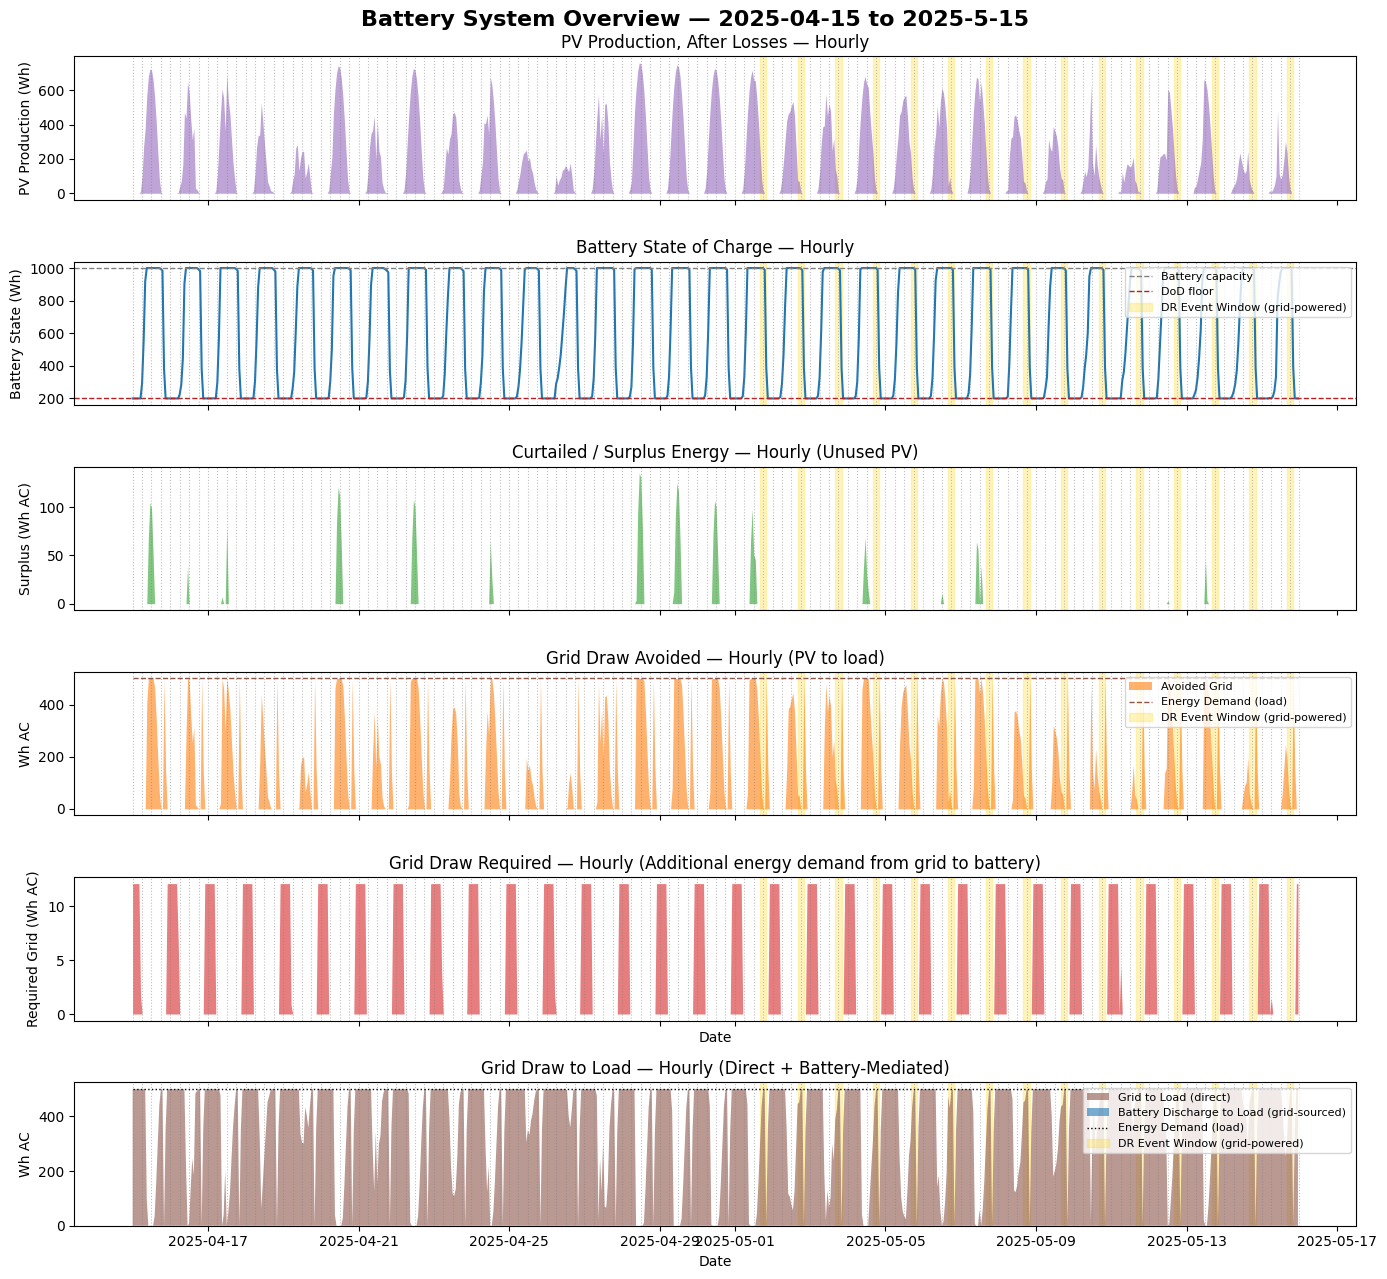

In [28]:
pv_production_arr = np.array([
    pv_to_stored_charge(getDegradedP(h, y), plugin, acToDC)
    for h in hourly_array_power_yield_test
])
idx = pd.date_range('2025-01-01', periods=len(g['batState']), freq='h')
df = pd.DataFrame(g, index=idx)
df['pvProductionWh'] = pv_production_arr
df['loadWAC'] = loadWAC
df['batteryDischargeToLoadWhAC'] = df['loadWAC'] - df['avoidedGridWhAC'] - df['grid_to_loadWhAC']
dodFloor = batWh * (1 - LiFePOdod)

# recreate the grid-window + DR-season mask the simulation used, so we can
# shade it on the plots (gridWindowLengthHours must match the value
# hardcoded inside simulate_hourly_energy)
gridWindowLengthHours = 4
hourOfDay = df.index.hour
dayOfYear = df.index.dayofyear
seasonEndDay = drSeasonStartDay + sum(daysInMonth) - 1
inSeason = (dayOfYear >= drSeasonStartDay) & (dayOfYear <= seasonEndDay)
inWindow = (
    (gridWindowStartHour is not None)
    & (hourOfDay >= (gridWindowStartHour or 0))
    & (hourOfDay < (gridWindowStartHour or 0) + gridWindowLengthHours)
)
df['inGridWindow'] = inSeason & inWindow

# zoom window -- 4 days
window = df.loc[window_start:window_end]

def get_event_spans(mask):
    """Collapse a boolean hourly Series into a list of (start, end) timestamp
    spans, so contiguous event hours become a single shaded block."""
    spans = []
    in_span = False
    start = None
    vals = mask.values
    times = mask.index
    for i in range(len(vals)):
        if vals[i] and not in_span:
            start = times[i]
            in_span = True
        elif not vals[i] and in_span:
            spans.append((start, times[i]))
            in_span = False
    if in_span:
        spans.append((start, times[-1] + pd.Timedelta(hours=1)))
    return spans

event_spans = get_event_spans(window['inGridWindow'])

fig, axes = plt.subplots(6, 1, figsize=(14, 13), sharex=True)

axes[0].fill_between(window.index, window['pvProductionWh'], color='tab:purple', alpha=0.6, linewidth=0)
axes[0].set_ylabel('PV Production (Wh)')
axes[0].set_title('PV Production, After Losses — Hourly')

axes[1].plot(window.index, window['batState'], linewidth=1.5, color='tab:blue')
axes[1].axhline(batWh, color='gray', linestyle='--', linewidth=1, label='Battery capacity')
axes[1].axhline(dodFloor, color='firebrick', linestyle='--', linewidth=1, label='DoD floor')
axes[1].set_ylabel('Battery State (Wh)')
axes[1].set_title('Battery State of Charge — Hourly')

axes[2].fill_between(window.index, window['surplusWhAC'], color='tab:green', alpha=0.6, linewidth=0)
axes[2].set_ylabel('Surplus (Wh AC)')
axes[2].set_title('Curtailed / Surplus Energy — Hourly (Unused PV)')

axes[3].fill_between(window.index, window['avoidedGridWhAC'], color='tab:orange', alpha=0.6, linewidth=0, label='Avoided Grid')
axes[3].plot(window.index, window['loadWAC'], color='tab:brown', linestyle='--', linewidth=1, label='Energy Demand (load)')
axes[3].set_ylabel('Wh AC')
axes[3].set_title('Grid Draw Avoided — Hourly (PV to load)')

axes[4].fill_between(window.index, window['requiredGridWhAC'], color='tab:red', alpha=0.6, linewidth=0)
axes[4].set_ylabel('Required Grid (Wh AC)')
axes[4].set_title('Grid Draw Required — Hourly (Additional energy demand from grid to battery)')
axes[4].set_xlabel('Date')

axes[5].stackplot(
    window.index,
    window['grid_to_loadWhAC'],
    window['batteryDischargeToLoadWhAC'],
    colors=['tab:brown', 'tab:blue'],
    alpha=0.6,
    labels=['Grid to Load (direct)', 'Battery Discharge to Load (grid-sourced)'],
)
axes[5].plot(window.index, window['loadWAC'], color='black', linestyle=':', linewidth=1, label='Energy Demand (load)')
axes[5].set_ylabel('Wh AC')
axes[5].set_title('Grid Draw to Load — Hourly (Direct + Battery-Mediated)')
axes[5].set_xlabel('Date')

# shade the DR event window on every panel
for ax_i, ax in enumerate(axes):
    for span_i, (span_start, span_end) in enumerate(event_spans):
        ax.axvspan(
            span_start, span_end,
            color='gold', alpha=0.25, zorder=0,
            label='DR Event Window (grid-powered)' if (ax_i in (1, 3, 5) and span_i == 0) else None,
        )

# vertical lines every 6 hours, across all panels, to align comparison
gridlines = pd.date_range(window.index[0].normalize(), window.index[-1] + pd.Timedelta(hours=1), freq='6h')
for ax in axes:
    for t in gridlines:
        ax.axvline(t, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)

# re-issue legends now that the shaded-span label has been added
for ax in (axes[1], axes[3], axes[5]):
    ax.legend(loc='upper right', fontsize=8)

fig.suptitle(f'Battery System Overview — {window_start} to {window_end}', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'outputs/tests/battery_system_overview_{window_start}_{window_end}_{plugin}.png', dpi=300, bbox_inches='tight')
plt.show()

## Economic Modeling & Hardware Costs

Components:

* CAPEX
* Grid electricity value (costs or avoided value)
* PBP
* NPV
* LCOE (LCOSS)

In [27]:
# #average inflation rate for 2024, based on NREL data from https://atb.nrel.gov/electricity/2024/definitions#inflation
# aIR = 0.025

realDiscountRate = 0.03 # 43 #2.2% real rate
# nominalDiscountRate = ((1 + realDiscountRate) * (1 + aIR))-1
# print(nominalDiscountRate)
discountRate = realDiscountRate #2% discount rate

# #returns inflation rate after Y years
# #args: year
# def infRate(y, r= aIR):
#     return (1+r)**y

# arguments: value to be inflated, year
# not used
def inflateIt(v,y):
    return v* infRate(y)

avgAnnualInc= 0.02
def annualCostIncrease(v,y):
    return v* ((1+avgAnnualInc)**y)
    
#args: value to be discounted, year
def discountIt(v, y,r =discountRate):
    return v/(1+r)**y

#inflateIt(10,4)

### Capital Expenses (CAPEX) i.e. upfront costs

In [28]:
# Upfront Costs

#args: pv watts
def getPVcost(w:int):
    #.7 is based on a 30% tax credit on PV modules
    taxCredit = 0 #.3 #IRA repealed by Trumps BS
    #assumes $0.5 per W modules
    modulePerW = 0.5

    return w * (1-taxCredit) * modulePerW

#this is the total initial expenditure
#args: pv watts, battery price, diy controller,  micro-inverter in use, operating expense
def getCAPEX(pvW:int,batPr:float,diy:bool=True,mi:bool=False,op:float=0.0):
    #total sales tax in NYC is 8.875% - no sales tax for non-profits
    salesTax =  0.08875 

    if pvW == 0:
        #fixed costs
        insulation = 0 #used for insulating cable entry
        pvCables = 0 #2x 10ft MC4 cables
    else:
        #fixed costs
        insulation = 6 #used for insulating cable entry
        pvCables = 1.5 * 20 #20ft pair MC4 cables @ $1.5/ft

    #variable costs
    mountDollarPerW = .4

    smartController = 0
    if diy:
        smartController = 115.74 #smart controller without RPi

    microinverter = 0
    if mi:
        microinverter = 325 #Price as on July 2026 - https://usa.apsystems.com/product/ez1-microinverter/

    rpi = 0
    if mi or diy:
        rpi = 62.75
        
        
    operatingCosts = op #DR aggregation operator costs are not considered here.
    
    fixedHardwareCosts = smartController + rpi + operatingCosts + insulation + pvCables + microinverter

    variableCosts = batPr + getPVcost(pvW) + (pvW * mountDollarPerW)

    return (fixedHardwareCosts + variableCosts) * (1 + salesTax)

#print(getCAPEX(100,200))


### Grid Electricity Costs

In [29]:
# GRID ELECTRICITY COSTS - CHANGE THIS TO JULY AND AUGUST AVG FOR ELEX!

# https://www.bls.gov/regions/northeast/news-release/averageenergyprices_newyork.htm accessed January 24, 2025
#monthlyResElecPricesDollars = [0.265,0.255,0.266,0.259,0.252,0.288,0.288,0.276,0.273,0.274,0.262,0.272]

# https://www.nyserda.ny.gov/Energy-Prices/Electricity/Monthly-Avg-Electricity-Residential
monthlyResElecPricesDollars = [0.284, 0.30, 0.286,0.2879,0.299,0.2979,0.2934,0.299,0.3046,0.3024,0.2957,0.3069]
#monthlyResElecPricesDollars = [0,0,0,0,0,0,0,0,0,0,0,0]

avgDollarsKw =round(sum(monthlyResElecPricesDollars)/len(monthlyResElecPricesDollars),4) 
print('12 Month NYS Residential Retail Electricity Average: $' + str(avgDollarsKw) + '/kWh')

#args: kWAC generated from PV, year from installation, month (either a for all or the number of the month-1)
def utilityCosts(kWAC,y=0, m='a'):

    if m=='a':
        price =round(sum(monthlyResElecPricesDollars)/len(monthlyResElecPricesDollars),4) 
    else:
        price=monthlyResElecPricesDollars[m]

    annualElectCosts = kWAC * annualCostIncrease(price,y) # this factors in annual grid price increases
    return annualElectCosts

print(utilityCosts(15,3))

12 Month NYS Residential Retail Electricity Average: $0.2964/kWh
4.718130768000001


In [30]:
def aggregate_hourly_to_monthly(hourly, year=2025):
    """
    Convert raw hourly arrays (already AC-equivalent Wh) into monthly kWAC
    surplus stats and annual totals, using a datetime index.

    avg/med/min/max_hourly_surpluskWAC_byMonth are computed as true daily
    averages of surplus hours (zero-surplus hours excluded from the
    per-day stat, matching the original per-day loop's behavior), then
    those daily stats are aggregated across each month.
    """
    idx = pd.date_range(start=f'{year}-01-01', periods=len(hourly['surplusWhAC']), freq='h')
    surplus = pd.Series(hourly['surplusWhAC'], index=idx) * 0.001  # Wh -> kWAC

    # NaN on zero-surplus hours so daily stats skip them, like the original
    surplus_nonzero = surplus.where(surplus > 0)
    daily_avg = surplus_nonzero.resample('D').mean().fillna(0)
    daily_med = surplus_nonzero.resample('D').median().fillna(0)
    daily_min = surplus_nonzero.resample('D').min().fillna(0)
    daily_max = surplus_nonzero.resample('D').max().fillna(0)
    daily_totals = surplus.resample('D').sum()

    return {
        'avg_hourly_surpluskWAC_byMonth': daily_avg.resample('ME').mean().tolist(),
        'med_hourly_surpluskWAC_byMonth': daily_med.resample('ME').median().tolist(),
        'min_hourly_surpluskWAC_byMonth': daily_min.resample('ME').min().tolist(),
        'max_hourly_surpluskWAC_byMonth': daily_max.resample('ME').max().tolist(),
        'ann_surpluskWhAC': daily_totals.sum(),
        'requiredGridWhAC_total': hourly['requiredGridWhAC'].sum(),
        'avoidedGridWhAC_total': hourly['avoidedGridWhAC'].sum(),
        'gridToLoadWhAC_total': hourly['grid_to_loadWhAC'].sum(),
    }

def apply_financials(agg, y, events, batWh, LiFePOdod, acToDC, iE):
    """
    Convert aggregated AC-equivalent energy totals into dollar values.
    No unit conversion happens here anymore — that's already done
    upstream in simulate_hourly_energy.
    """
    requiredGridkWhAC = agg['requiredGridWhAC_total'] * 0.001
    avoidedGridkWhAC = agg['avoidedGridWhAC_total'] * 0.001
    gridToLoadkWhAC = agg['gridToLoadWhAC_total'] * 0.001

    # top off from grid for events — round-trip conversion loss vs. going
    # direct from grid to load
    eventGridCharge_kWhAC = events * ((batWh * LiFePOdod_event * 0.001) / acToDC) 
    eventBatteryOutputkWhAC_fromGrid = eventGridCharge_kWhAC * acToDC * iE

    return {
        'avg_hourly_surpluskWAC_byMonth': agg['avg_hourly_surpluskWAC_byMonth'],
        'med_hourly_surpluskWAC_byMonth': agg['med_hourly_surpluskWAC_byMonth'],
        'min_hourly_surpluskWAC_byMonth': agg['min_hourly_surpluskWAC_byMonth'],
        'max_hourly_surpluskWAC_byMonth': agg['max_hourly_surpluskWAC_byMonth'],
        'ann_surpluskWhAC': agg['ann_surpluskWhAC'],
        'ann_surpluskWhAC_value': utilityCosts(agg['ann_surpluskWhAC'], y),
        'requiredGridkWhAC': requiredGridkWhAC,
        'requiredGridkWhAC_cost': utilityCosts(requiredGridkWhAC, y),
        'eventGridChargekWhAC': eventGridCharge_kWhAC,
        'eventGridChargekWhAC_cost': utilityCosts(eventGridCharge_kWhAC,y,6), #base the cost off of July rates
        'eventBatteryOutputkWhAC_fromGrid': eventBatteryOutputkWhAC_fromGrid,
        'avoidedGridkWhAC': avoidedGridkWhAC,
        'avoidedGridkWhAC_value': utilityCosts(avoidedGridkWhAC, y),
        'gridToLoadkWhAC': gridToLoadkWhAC,
    }

# def getGridValueHourly(pvYieldW, batWh, loadWAC, iE, events=5, y=0, plugin=True):
#     hourly = simulate_hourly_energy(
#         pvYieldW, batWh, loadWAC, iE, y, plugin,
#         dailySelfConsumptionWhDC=dailySelfConsumptionWhDC,
#         LiFePOdod=LiFePOdod, acToDC=acToDC,
#     )
#     agg = aggregate_hourly_to_monthly(hourly)
#     return apply_financials(agg, y, events, batWh, LiFePOdod, acToDC, iE)
def getGridValueHourly(pvYieldW, batWh, loadWAC, iE, events=5, y=0, plugin=True, seasonal=False):
    """
    seasonal=False (default): loadWAC is treated as a constant load all
    year round (e.g. a fridge).
    seasonal=True: loadWAC is only applied during the DR season (May-Sep)
    and treated as zero the rest of the year (e.g. an AC unit) -- built
    via build_seasonal_load_array so it lines up with pvYieldW hour-for-hour.
    """
    n_hours = len(pvYieldW)
    loadWAC_hourly = build_seasonal_load_array(loadWAC, seasonal=seasonal, n_hours=n_hours)

    hourly = simulate_hourly_energy(
        pvYieldW, batWh, loadWAC_hourly, iE, y, plugin,
        dailySelfConsumptionWhDC=dailySelfConsumptionWhDC,
        LiFePOdod=LiFePOdod, acToDC=acToDC,
    )
    agg = aggregate_hourly_to_monthly(hourly)
    return apply_financials(agg, y, events, batWh, LiFePOdod, acToDC, iE)

    

In [41]:
getGridValueHourly(list(hourly_array_power_yield_test), 0,100,.85)

{'avg_hourly_surpluskWAC_byMonth': [0.16579352500956457,
  0.25230772216230546,
  0.2625913248810264,
  0.26366936551567444,
  0.2550515670994026,
  0.2435106510376038,
  0.23810766613996906,
  0.25577247721923163,
  0.2700965692873839,
  0.24288183300018815,
  0.2320376033032012,
  0.1916009349562951],
 'med_hourly_surpluskWAC_byMonth': [0.17804641631148627,
  0.23384180084435047,
  0.3199751208607408,
  0.3235843845405033,
  0.28570017047676005,
  0.2833959179129124,
  0.27595977433132823,
  0.335226411489141,
  0.316941806691839,
  0.2853519891410526,
  0.22118827461527585,
  0.1595639836471554],
 'min_hourly_surpluskWAC_byMonth': [0.0,
  0.0,
  0.0020471686388288932,
  0.0,
  0.0001761738856786792,
  0.0002497153436717241,
  0.00010946375754245707,
  0.0,
  0.001355137490401674,
  0.0,
  0.0,
  0.0],
 'max_hourly_surpluskWAC_byMonth': [0.5549364845882276,
  0.6830578855303004,
  0.6770546393054945,
  0.6588054328751661,
  0.6153551317472501,
  0.5739472597812805,
  0.55643333739723

### Payback Period

Payback Period = Initial Investment / Annual Value

In [32]:
#args: capex, grid value, DR revenue
# returns PBP in years
def getPBP(c:float,g:Dict[str,List[float]],dr:list[float])->Dict[str,float]:
    # gK = ['requiredGridkWhAC_cost','eventGridChargekWhAC_costs','avoidedGridkWhAC_value']
    # gKS = ['ann_surpluskWhAC_value']
    
    pbp = {'without_surplus':0,'with_surplus':0}
    avgDr = mean(dr)
    
    gridBalance = mean(g['avoidedGridkWhAC_value']) - mean(g['requiredGridkWhAC_cost']) - mean(g['eventGridChargekWhAC_cost'])
    pbp['without_surplus'] = c/(gridBalance+avgDr)
    pbp['with_surplus'] = c/(gridBalance+avgDr+mean(g['ann_surpluskWhAC_value']))

    return pbp
    
# cTest =  300
# gTest ={'daysWithSurplus': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'avgHourlySurpluskWAC': 0.0, 'maxHourlySurpluskWAC': 0.0, 'ann_surpluskWhAC': [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)], 'ann_surpluskWhAC_value': [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)], 'requiredGridkWhAC': [np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895)], 'requiredGridkWhAC_cost': [np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053)], 'eventGridChargekWhAC': [np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632)], 'eventGridChargekWhAC_cost': [np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687)], 'avoidedGridkWhAC': [np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394)], 'avoidedGridkWhAC_value': [np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299)]}
# drTest = [np.float64(8.32920429661677), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(3.1849880941306794), 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, np.float64(15.656175588316744), 28.0, 28.0, 28.0, 28.0, 28.0, 28.0, 28.0, 28.0, 28.0]
#getPBP(cTest,gTest,drTest)

### Net Present Value (NPV)

NPV = ∑ (Cash flow / (1 + i)^t) – initial investment

In [33]:
# args: capex, grid value, dr value
def getNPV(c, g, dr):
    subC = -1 * c
    npv = {'without_surplus':subC,'with_surplus':subC}
    wl = min(10, len(dr))
    
    for y in range(wl):
        cashFlow = g['avoidedGridkWhAC_value'][y] - g['requiredGridkWhAC_cost'][y] - g['eventGridChargekWhAC_cost'][y] +dr[y]
        npv['without_surplus'] += (discountIt(cashFlow,y))
        npv['with_surplus'] += (discountIt(cashFlow+g['ann_surpluskWhAC_value'][y],y)) 
    return npv

# cTest =  300
# gTest ={'daysWithSurplus': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'avgHourlySurpluskWAC': 0.0, 'maxHourlySurpluskWAC': 0.0, 'ann_surpluskWhAC': [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)], 'ann_surpluskWhAC_value': [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)], 'requiredGridkWhAC': [np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895)], 'requiredGridkWhAC_cost': [np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053)], 'eventGridChargekWhAC': [np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632)], 'eventGridChargekWhAC_cost': [np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687)], 'avoidedGridkWhAC': [np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394)], 'avoidedGridkWhAC_value': [np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299)]}
# drTest = [np.float64(8.32920429661677), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(3.1849880941306794), 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, np.float64(15.656175588316744), 28.0, 28.0, 28.0, 28.0, 28.0, 28.0, 28.0, 28.0, 28.0]
# getNPV(cTest,gTest,drTest)

### Levelized Cost of Solar plus Storage (LCOSS)

Total Costs ($)/ Total Energy (kWAC)

In [34]:
#returns the dollar value of the module at the end of the system's working like
# factors in module degradation 
# args: PV watts nameplate,year
def getResidualValue(w,y):
     return getPVcost(getDegradedP(w,y)) #inflateIt(getPVcost(getDegradedP(w,y)),y)
 
#test
#getResidualValue(100, 8.3)

In [35]:
# capex, gridValue, pv watts, constant load W
def getLCOSS(c, g, w, loadWAC):
    resVal = getResidualValue(w, min(len(d), 10))
    wl = len(g['avoidedGridkWhAC_value'])
    totalLoadkWhAC = loadWAC * 8760 * 0.001

    lcoss = {'without_surplus': 0, 'with_surplus': 0}

    for variant in lcoss:
        num = c - discountIt(resVal, wl - 1)
        den = 0
        for y in range(wl):
            num += discountIt(g['requiredGridkWhAC_cost'][y] + g['eventGridChargekWhAC_cost'][y], y)

            selfSuppliedkWhAC = totalLoadkWhAC - g['gridToLoadkWhAC'][y]

            # self supplied is only not used in off-grid mode when PV=0, in this situation it defaults to the battery output for the events only
            energy = max(selfSuppliedkWhAC,g['eventBatteryOutputkWhAC_fromGrid'][y])
                
            if variant == 'with_surplus':
                energy += g['ann_surpluskWhAC'][y]
            den += discountIt(energy, y)

        lcoss[variant] = num / den if den != 0 else float('nan')

    return lcoss

In [36]:
# '''
# LEVELIZED COST OF SOLAR plus STORAGE
# Numerator = CAPEX + O&M (Cost of purchased electricity) - RESIDUAL VALUE
# Denomenator = PV WhAC Yield + ELEC FROM GRID TO BATTERY AND BACK (Note self consumption included in PV WhAC)

# Everything gets discounted and not inflated!
# '''

# # capex, gridValue, pv watts, solarYield kWh, effective efficiency
# def getLCOSS(c, g, w, sYkW, eE):
#     # calculate residual solar panel value (includes inflation)
#     resVal =  getResidualValue(w,min(len(d),10))
 
#     wl = len(g['avoidedGridkWhAC_value']) #working life

#     #ann_surpluskWhAC_value

    
#     lcoss = {'without_surplus':0,'with_surplus':0}       
   
#     num = c - discountIt(resVal,wl-1)
#     den = 0
#     for y in range(wl):
#         # costs
#         num += discountIt(g['requiredGridkWhAC_cost'][y] + g['eventGridChargekWhAC_cost'][y],y)
        
#         #PV to bat to load
#         stbtl = discountIt(g['avoidedGridkWhAC'][y]* eE,y)
#         #Grid to battery to load
#         gtbtl = discountIt((g['requiredGridkWhAC'][y]+g['eventGridChargekWhAC'][y])*.95*eE,y)
#         den += stbtl + gtbtl  #total solar production + total from grid

#     lcoss['without_surplus']=num/den

#     num = c - discountIt(resVal,wl-1)
#     den = 0
#     for y in range(wl):
#         num += discountIt(g['requiredGridkWhAC_cost'][y] + g['eventGridChargekWhAC'][y],y)
        
#         #PV to bat to load
#         stbtl = discountIt(g['avoidedGridkWhAC'][y],y)
#         #Grid to battery to load
#         gtbtl = discountIt((g['requiredGridkWhAC'][y]+g['eventGridChargekWhAC'][y])*.95*eE,y) + discountIt(g['ann_surpluskWhAC'][y],y)
#         den += stbtl + gtbtl  #total solar production + total from grid

#     lcoss['with_surplus']=num/den

#     return lcoss

# cTest = 799.7739750000002
# gTest ={'daysWithSurplus': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'avgHourlySurpluskWAC': 0.0, 'maxHourlySurpluskWAC': 0.0,
#         'ann_surpluskWhAC': [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)],
#         'ann_surpluskWhAC_value': [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)],
#         'requiredGridkWhAC': [np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895)],
#         'requiredGridkWhAC_cost': [np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053)],
#         'eventGridChargekWhAC': [np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632)],
#         'eventGridChargekWhAC': [np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687)],
#         'avoidedGridkWhAC': [np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394)],
#         'avoidedGridkWhAC_value': [np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299)]}
# wTest =0
# sYkWTest = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
# eETest = 0.849849430313522
 
# getLCOSS(cTest,gTest,wTest,sYTest,eETest) 

## Automated DR Participation

In [37]:
# returns the max value for a given load - does not consider the ability to meet the load needs
def drMaxValue(loadW, cRate, dRate, prefix=''):
    m=5 # months in the DR season
    annValResProgram_csrp = loadW * .001 * cRate * m #CSRP reservation value for full coverage of load
    annValResProgram_dlrp = loadW * .001 * dRate * m #DLRP reservation value for full coverage of load
    annValResTot = annValResProgram_csrp + annValResProgram_dlrp # Total DR reservation value for full coverage
    annValPer_csrp = loadW * .001 * csrpEvents #CSRP performance value for full coverage of load
    annValPer_dlrp = loadW * .001 * dlrpEvents #DLRP performance value for full coverage of load
    annValPer = annValPer_csrp + annValPer_dlrp #total performance value for full coverage of load
    annTotVal = annValResTot + annValPer # total value for full coverage of load

    drv = {
        f"{prefix}annValResProgram_csrp" : annValResProgram_csrp,
        f"{prefix}annValResProgram_dlrp" : annValResProgram_dlrp,
        f"{prefix}annValResTot" : annValResTot,
        f"{prefix}annValPer_csrp" : annValPer_csrp,
        f"{prefix}annValPer_dlrp" : annValPer_dlrp,
        f"{prefix}annValPer" : annValPer,
        f"{prefix}annTotVal" : annTotVal
    }
    return drv

# returns percentage of the load that can be addressed and the annual dollar value
def drFlexValue(drkWACtotal_y, loadkW, rate, eventNum, replacement_kW=0, prefix=''):
    res = {}
    if replacement_kW ==0:
        cPerc = drkWACtotal_y/loadkW # percentage of load covered
        cFlexedkW = min(drkWACtotal_y,loadkW) #kWAC flexed up to baseline
        resInc = cFlexedkW * rate * 5 # annual reservation income
        perfInc = cFlexedkW * 4 * eventNum # annual performance income
    else:
        cPerc = drkWACtotal_y/replacement_kW # percentage of load covered
        cFlexedkW = loadkW * min(1,cPerc)  # the replacement is scaled based on the percentage of the event the replacement load can run for
        resInc = cFlexedkW * rate * 5# annual reservation income
        perfInc = cFlexedkW * 4 * eventNum # annual performance income (rate is $1/kWh)
    res['cPerc']=cPerc
    res['inc'] = resInc + perfInc
    res['flex'] = cFlexedkW
    return res

In [38]:

#get the available hourly watts if the battery is fully depleted over 4 hours
#arg: battery WhDC
# no longer used
def getFourHourW(bWh:float):
    return bWh * LiFePOdod * .25

In [152]:
def solarEventYieldkWAC(pvWyield, iE, sT, iM, year=0, plugin=False) -> list:
    #daysInMonth = [31, 30, 31, 31, 30]
    elapsedDays = drSeasonStartDay  # May 1

    eff_mult = 1.0 if plugin else iE
    degrade = (1 - DEG_RATE) ** year   # <-- computed once, not per-hour

    monthly = []
    for dim in daysInMonth:
        # build hour indices for the 4 event hours, every day in this month
        day_starts = ((np.arange(elapsedDays, elapsedDays + dim) - 1) * 24) + sT
        hour_idx = day_starts[:, None] + np.arange(4)   # shape (dim, 4)
        window = pvWyield[hour_idx]                      # shape (dim, 4)

        daily_kwh = window.sum(axis=1) * eff_mult * 0.001 * 0.25  # per-day event kWh
        monthly.append(daily_kwh.mean())

        elapsedDays += dim

    # apply degradation once at the end, to every month at once
    return [m * degrade for m in monthly]

def solarPriorEventYieldWDC(pvWyield, sT, year=0) -> list:
    elapsedDays = drSeasonStartDay

    degrade = (1 - DEG_RATE) ** year  # computed once, not per-hour

    monthlyAvg = []
    for dim in daysInMonth:
        # hour indices for hours 0..sT-1, for every day in this month
        day_starts = (np.arange(elapsedDays, elapsedDays + dim) - 1) * 24
        hour_idx = day_starts[:, None] + np.arange(sT)   # shape (dim, sT)
        window = pvWyield[hour_idx]                       # shape (dim, sT)

        daily_WhDC = window.sum(axis=1)          # undegraded WhDC per day
        monthlyAvg.append(daily_WhDC.mean() * degrade)   # avg across days in month

        elapsedDays += dim

    return monthlyAvg

## Main Loop

This loop generates all the possible combinations of hardware and their energy and economic characteristics based on the constraints of the battery. 

In [153]:
#these networks are selected because they represent all possible combinations of characteristics

#myNetworks2023 = ['city hall','long island city','crown heights','randalls island', 'millwood west', 'grasslands','fresh kills','central bronx','northeast bronx']

In [154]:
yieldData = getYieldData(tilt, gamma_pdc)
#print(yieldData['180']['40'])

In [155]:
# check structure of output from above if needed
def key_outline(obj, indent=0):
    if isinstance(obj, dict):
        for k, v in obj.items():
            print("  " * indent + str(k))
            key_outline(v, indent + 1)
    elif isinstance(obj, pd.DataFrame):
        print("  " * indent + f"[DataFrame columns: {list(obj.columns)}]")
    elif isinstance(obj, (list, tuple)) and obj:
        key_outline(obj[0], indent + 1)

#key_outline(yieldData)

In [159]:
# True = quick test, false = full run
testMode = False
testModeNetworks = testMode
testModeBatteries = False
testModeAzimuth = True
testModePV = testMode
testModeF = True
testModeMI = False

# print('test mode: ' + str(testMode))

# print('loop start time:')
# print(datetime.now())

# network max DR values ($) by load scenario
nData = {
        'network':[],
        'load1W':[],
        'load2W':[],
        'load1RW':[],
        'l1_annValResProgram_csrp' : [],
        'l1_annValResProgram_dlrp' : [],
        'l1_annValResTot':[],
        'l1_annValPer_csrp' : [],
        'l1_annValPer_dlrp' : [],
        'l1_annValPer' : [],
        'l1_annTotVal' : [],
        'l2_annValResProgram_csrp' : [],
        'l2_annValResProgram_dlrp' : [],
        'l2_annValResTot':[],
        'l2_annValPer_csrp' : [],
        'l2_annValPer_dlrp' : [],
        'l2_annValPer' : [],
        'l2_annTotVal' : []
        }

rData = {
        'network':[],
        'eventStart':[],
        'dlrp_rate':[],
        'csrp_rate':[],
        'az':[],
        'pvW':[],
        'microinverter':[],
        'batModel':[],
        'batWh':[],
        'batWhAC':[],
        'effEff':[],#effective real efficiency
        'dischargeRateW':[],
        'capex':[],

        'cycles':[],
        'lifespan':[],
        'workingLife':[],
        'dailyPVWhAC_4M':[], #year 1 PV yields AC: min, max, mean, median
        'annualPVkWhDC_degraded':[],
        'annualPVkWhAC_degraded':[],
        'immediateEventAmt':[],

        'csrpMaxFlex':[],
        'csrpLoad1_flex':[],
        'csrpLoad2_flex':[],
        'csrpLoad1replacement_flex':[],
        'csrpLoad1_percentage':[],
        'csrpLoad2_percentage':[],
        'csrpLoad1replacement_percentage':[],
        'csrpLoad1Income':[],
        'csrpLoad2Income':[],
        'csrpLoad1RIncome':[],

        'dlrpMaxFlex':[],
        'dlrpLoad1_flex':[],
        'dlrpLoad2_flex':[],
        'dlrpLoad1replacement_flex':[],
        'dlrpLoad1_percentage':[],
        'dlrpLoad2_percentage':[],
        'dlrpLoad1replacement_percentage':[],
        'dlrpLoad1Income':[],
        'dlrpLoad2Income':[],
        'dlrpLoad1RIncome':[],

        'annDRIncomeLoad1': [],
        'annDRIncomeLoad2': [],
        'annDRIncomeLoad1R': [],

        'gridValue_load1':[],
        'gridValue_load2':[],
        'gridValue_load1R':[],
        
        'load1_NPV':[],
        'load2_NPV':[],
        'load1R_NPV':[],
    
        'load1_PBP':[], #real rate of return includes inflation and PV degradation (does not include discount rate)
        'load2_PBP':[],
        'load1R_PBP':[],

        'load1_LCOSS':[],
        'load2_LCOSS':[],
        'load1R_LCOSS':[]
    }

In [160]:
print('Go!')

Go!


In [161]:
'''
keys questions
PV usage all year round -> avoided grid costs?
battery % gaurantees
impact of controls (does this need a test?)
'''
print(f'Test mode: {testMode}')
st = datetime.now()
print(f'loop start time:{st}')
print('')

# reset rData just in case
for k,v in rData.items():
    rData[k] = []

csrpEvents = 4 # number of CSRP events annually
dlrpEvents = 1 # number of DLRP events annually
months = 5 # number of months DR programs run
programs = 2 # number of programs

years = 10 # max years

#diyBool = False

# also run it for max load
# loadOneW = 500 # AC
# loadTwoW = 100 # fridge
# loadOneW_Replacement = 80 # Fan

loads = {'loadOneW':1000, # AC
        'loadTwoW':100, # fridge
        'loadOneW_Replacement':75} # fan


######################
##### TEST SETUP #####
######################
loopCount = []
loopNumber = 0

if testModeNetworks:
    myNetworks = ['bowling green','sunnyside']
else:
    #these networks are selected because they represent all possible combinations of characteristics
    myNetworks = ['bowling green','long island city','sunnyside','grasslands','fresh kills','northeast bronx']

#loop through all networks
loopCount.append(len(myNetworks))

if testModeBatteries:
    bRange = range(16,29) #[26]
else:  
    bRange = range(hardware_df.shape[0])
loopCount.append(len(bRange))

if testModePV:
    pRange = [0,100,800]#range(0,30,10)
else:
    #loop through all allowed PV modules sizes, incrementing by 20W
    pRange = range(0,pvMaxW +50,50)
loopCount.append(len(pRange))

if testModeAzimuth: #) or (pW == 0):
    aRange = [180]
else:
    #loop through 3 azimuths
    aRange = [110,180,250]
loopCount.append(len(aRange))

if testModeF:
    fRange = [0]
else:
    fRange = [0,1,6]
loopCount.append(len(fRange))

if testModeMI:
    miRange = [False]
else:
    miRange = [True,False]
loopCount.append(len(miRange))

# ---- accurate loop count, respecting the Max PV Watts skip ----
# for each battery, count how many pW values in pRange it can actually support
validPVCountsPerBattery = []
for b in bRange:
    maxPVW = hardware_df.iloc[b]['Max PV Watts']
    validPVCountsPerBattery.append(sum(1 for pW in pRange if pW <= maxPVW))

# networks * mi * aRange * fRange are independent of the skip,
# only pRange x battery combos are filtered
loopCountInt = (
    len(myNetworks)
    * len(miRange)
    * len(aRange)
    * len(fRange)
    * sum(validPVCountsPerBattery)
)


dlrpStartC = 15 # needed for estimating PV contribution
dlrpStartI = 16.5 # needed for estimating PV contribution
####################
##### RUN TEST #####
####################
for n in myNetworks:
    
    print(n)
    startTime = getStartTime(n)

    #monthly income from DR participation
    #the DR rate for each program
    dlrp_rate= getDLRPrate(n)
    csrp_rate = getCSRPrate(n)
        
    loadOneDR = drMaxValue(loads['loadOneW'],csrp_rate,dlrp_rate,"l1_")
    #print(loadOneDR)
        
    loadTwoDR = drMaxValue(loads['loadTwoW'],csrp_rate,dlrp_rate,"l2_")
    #print(loadTwoDR)

    ###### package network data (hardware agnostic) #########
    nData['network'].append(n)
    nData['load1W'].append(loads['loadOneW'])
    nData['load2W'].append(loads['loadTwoW'])
    nData['load1RW'].append(loads['loadOneW_Replacement'])
    #merged = {**dict2, **dict1}
    # nData['load1MaxDRInc'].append(loadOneDR)
    # nData['load2MaxDRInc'].append(loadTwoDR)

    # Unpack loadTwoDR into nData
    for k, v in loadOneDR.items():
        nData[k].append(v)
    # Unpack loadTwoDR into nData
    for k, v in loadTwoDR.items():
        nData[k].append(v)

    #loop through all batteries in database
    for b in bRange:

        #print('')
        #get battery info - controllable devices only
        d = hardware_df.iloc[b]
        #print(d)
    
        bWh = d['Battery Wh']
        bModel = d['Model']
        
        #time in hours it takes to charge the battery
        #from 0% to 100% from the grid
        bCT = d['Full Grid Charge Hours']
        #from 80% to 100% from grid
        bFCT = d['Full Grid Charge Hours']-d['80 Per Grid Charge Hours']
        #the charge time from 20% to 100%
        practicalBCT = (d['80 Per Grid Charge Hours'] * .75) + bFCT #this is what we care about for DR
        #print(f'20-100% Charge Time: {round(practicalBCT,3)} hours')

        #convert to AC
        #battery is depleted 80% at 4-hour rate
        fH = bWh * LiFePOdod * .25 # getFourHourW(bWh) 
        
        #effective efficiency is the actualy efficiency when consuming power at the 4 hour rate
        effectiveEfficiency = d['Inverter Efficiency']
    
        #bat capacity down to DoD
        realBWh = bWh * LiFePOdod
        
        #bat WhAC capacity
        bWhAC = realBWh * effectiveEfficiency
        #print(f'Battery Capacity: {round(bWhAC,3)} WhAC')

        #loadMaxBatDR = drMaxValue(bWhAC/4,csrp_rate,dlrp_rate) # not doing anthing with this yet
        #print(loadMaxBatDR)

        #life span assumes 1 full cycle a day
        lS = d['Cycles']/365
        #working life caps the lifespan at 10 years
        wL = min(10,lS)
        wLrounded = math.ceil(wL) # round wL up for some calculations

        # include plug-in micro inverter in model
        for m in miRange:
            miBool = m
            
            for pW in pRange:
    
                #if the array exceeds the power station capacity, skip it
                if pW > d['Max PV Watts']:
                    continue
    
                #Hardware Costs in Dollars
                diyBool = not d['official API']
                capex =getCAPEX(pW,d['retail price'],diyBool,miBool)
        
                for a in aRange:
    
                    ################
                    ###### PV ######
                    ################
                    
                    csrpPV_kWAC = [] # avg PV production during event, by month 
                    #dlrpPV_kWAC = [] # pv production average for July
                    #priorCSRP_WDC = [] #not required
                    #priorDRLP_WDC = []
                    
                    if pW != 0:
                        #get hourly power yields for a given array size
                        if miBool:
                            hourly_array_power_yield=np.asarray(yieldData[str(a)][str(pW)]['hourly']['yieldAC'])
                        else:
                            hourly_array_power_yield=np.asarray(yieldData[str(a)][str(pW)]['hourly']['yieldDC'])
                        
                        for y in range(wLrounded):
                            # these are the solar yields during events - double check!
                            monthlyYields = solarEventYieldkWAC(hourly_array_power_yield,d['Inverter Efficiency'],startTime,d['Inverter Watts'], y, miBool)
                            csrpPV_kWAC.append([monthlyYields[2],monthlyYields[2],monthlyYields[2],monthlyYields[3],monthlyYields[3]])
                            #priorCSRP_WDC.append(solarPriorEventYieldWDC(array_power_yield['yield'],startTime,y))
    
                        if miBool:
                            daily_array_power_yield=yieldData[str(a)][str(pW)]['daily']['dailyAC']
                        else:
                            daily_array_power_yield=yieldData[str(a)][str(pW)]['daily']['dailyDC'] 
                        
                    else: # fill it with zeros
                        for y in range(wLrounded):
                            csrpPV_kWAC.append([0,0,0,0,0])
                            # dlrpPV_kWAC.append(0)
                            # priorDRLP_WDC.append(0)
    
                        daily_array_power_yield = [0] * 365
                        hourly_array_power_yield  = np.asarray([0] * 365 * 24)

                    # this needs to be fixed for plugin options
                    minDailyYieldWhAC = (min(daily_array_power_yield) - dailySelfConsumptionWhDC)* effectiveEfficiency
                    maxDailyYieldWhAC = (max(daily_array_power_yield) - dailySelfConsumptionWhDC)* effectiveEfficiency
                    meanDailyYieldWhAC = (mean(daily_array_power_yield) - dailySelfConsumptionWhDC)* effectiveEfficiency
                    medianDailyYieldWhAC = (median(daily_array_power_yield) - dailySelfConsumptionWhDC)* effectiveEfficiency
                    
                    #year 1 PV daily yields: min, max, mean, median
                    #this is what needs to be consumed to avoid curtailment
                    pvDailyWhAC_4M = [minDailyYieldWhAC,maxDailyYieldWhAC,meanDailyYieldWhAC,medianDailyYieldWhAC]
                    
                    annualPVkWhDC_degraded = []
                    annualPVkWhAC_degraded = []
                    for y in range(wLrounded):
                        annualPVkWhDC_degraded.append(getDegradedP(sum(daily_array_power_yield),y)*0.001)
                        annualPVkWhAC_degraded.append(annualPVkWhDC_degraded[-1] * 0.001 * effectiveEfficiency)
                    
                    ################
                    ##### Grid #####
                    ################
    
                    # creates a list by load scenarios
                    gridValue = {}

                    # loadOneW (AC) and the loadOneW_Replacement (fan)
                    # are only actually drawing power during the DR
                    # season (May-Sep); loadTwoW (fridge) runs all year round. 
                    # getGridValueHourly builds the right hourly load profile internally based on the seasonal flag.
                    seasonalLoads = {'loadOneW': True, 'loadTwoW': False, 'loadOneW_Replacement': True}

                    for k,l in loads.items(): 
                        gVL = {}
                        for y in range(wLrounded):
                            if d['Inverter Watts'] < l: #if the inverter can't support the load
                                l = 0
                            # if k in ['loadOneW']:#,'load1W_Replacement']:
                            #     l = 0
                            # grid value includes inflation on electricity prices
                            #for kr, v in getGridValueHourly(list(hourly_array_power_yield), bWh,l,effectiveEfficiency,csrpEvents+dlrpEvents,y,plugin=miBool).items():
                            for kr, v in getGridValueHourly(list(hourly_array_power_yield), bWh,l,effectiveEfficiency,csrpEvents+dlrpEvents,y,plugin=miBool,seasonal=seasonalLoads[k]).items():
                                if kr in gVL.keys():
                                    gVL[kr].append(v)
                                else:
                                    gVL[kr] = [v]
                        for gk in gVL.keys():
                            if gk in ['avg_hourly_surpluskWAC_byMonth','med_hourly_surpluskWAC_byMonth','min_hourly_surpluskWAC_byMonth','max_hourly_surpluskWAC_byMonth']:
                                gVL[gk] = gVL[gk][0] # take just the first year, before PV degradation kicks in
                                
                        gridValue[k]=gVL
    
                    ################
                    ##### CSRP #####
                    ################
                    loadOne_kW = loads['loadOneW']*.001
                    loadTwo_kW = loads['loadTwoW']*.001
                    loadOneReplacement_kW = loads['loadOneW_Replacement']*.001
                    
                    # csrp charge time : adjust battery capacity based on charge time
                    # can battery be fully charged in less than 21 hours?
                    if practicalBCT <= 21:
                        FbWh = realBWh 
                    else: 
                        FbWh = min(realBWh,realBWh * (21/practicalBCT))
            
                    csrpkWAC_total = [] # max flexibility (avg of all months)
                    csrpLoad1_flex = []
                    csrpLoad2_flex = []
                    csrpLoad1replacement_flex = []
                    csrpLoad1_percentage = [] # percentage of baseline load directly addressible through CSRP
                    csrpLoad2_percentage = [] # percentage of baseline load directly addressible through CSRP
                    csrpLoad1replacement_percentage = [] # percentage of baseline load directly addressible through CSRP (with curtailing L1)
                    csrpLoad1_Income = []
                    csrpLoad2_Income = []
                    csrpLoad1replacement_Income = []
    
                    for y in range(wLrounded):
                        # csrp has a 21-hour notice, so always fully charged
                        csrpkWAC_atStart = (((FbWh/4)-scWDC)*effectiveEfficiency * .001)#csrp capacity at start of event
                        csrpkWAC_total.append(csrpkWAC_atStart + mean(csrpPV_kWAC[y])) #taking the avg of all months works here, because specific months were selected above
    
                        # load 1
                        fVresults = drFlexValue(csrpkWAC_total[y], loadOne_kW, csrp_rate, csrpEvents)
                        csrpLoad1_flex.append(fVresults['flex'])
                        csrpLoad1_percentage.append(fVresults['cPerc'])
                        csrpLoad1_Income.append(fVresults['inc']) #the season is 5 months long
    
                        # load 2
                        fVresults = drFlexValue(csrpkWAC_total[y], loadTwo_kW, csrp_rate, csrpEvents)
                        csrpLoad2_flex.append(fVresults['flex'])
                        csrpLoad2_percentage.append(fVresults['cPerc'])
                        csrpLoad2_Income.append(fVresults['inc']) #the season is 5 months long
    
                        # load 1 Replacement
                        fVresults = drFlexValue(csrpkWAC_total[y], loadOne_kW, csrp_rate, csrpEvents,loadOneReplacement_kW)
                        csrpLoad1replacement_flex.append(fVresults['flex'])
                        csrpLoad1replacement_percentage.append(fVresults['cPerc'])
                        csrpLoad1replacement_Income.append(fVresults['inc'])#the season is 5 months long
    
                    ################
                    ##### DLRP #####
                    ################
                    
                    #immediate event frequency
                    for i in fRange:
                        loopNumber += 1
                        if loopNumber == 1 or loopNumber % 100 == 0:
                            et = (datetime.now() - st).total_seconds()
                            tr = round(((et / loopNumber) * (loopCountInt - loopNumber)) / 60, 2)
                            print(f'{loopNumber} of {loopCountInt} : {tr} minutes estimated remaining')
    
                        dlrpkWAC_total = [] # max flexibility (avg of all months)
                        dlrpLoad1_flex = []
                        dlrpLoad2_flex = []
                        dlrpLoad1replacement_flex = []
                        dlrpLoad1_percentage = [] # percentage of baseline load directly addressible through CSRP
                        dlrpLoad2_percentage = [] # percentage of baseline load directly addressible through CSRP
                        dlrpLoad1replacement_percentage = [] # percentage of baseline load directly addressible through CSRP (with curtailing L1)
                        dlrpLoad1_Income = []
                        dlrpLoad2_Income = []
                        dlrpLoad1replacement_Income = []
    
                        priorDRLP_WDC = []
                        dlrpPV_kWAC = []
    
                        for y in range(wLrounded):
                            #determine if its a contingency year or an emergency year
                            if i == 0: 
                                eventType = 'c'
                                dlrpStart = dlrpStartC
                            else:
                                if y < i:
                                    eventType ='i'
                                    dlrpStart = dlrpStartI
                                else:
                                    eventType ='c'
                                    dlrpStart = dlrpStartC
                            
                            if pW != 0:
                                #for yw in range(wLrounded):
                                priorDRLP_WDC.append(solarPriorEventYieldWDC(hourly_array_power_yield,round(dlrpStart),y)[2]) #compare this with the older morningYield function
                                dlrpPV_kWAC.append(solarEventYieldkWAC(hourly_array_power_yield,d['Inverter Efficiency'],round(dlrpStart),d['Inverter Watts'], y,miBool)[2]) #dlrp starts at 10am
                            else: # fill it with zeros
                                #for yw in range(wLrounded):
                                dlrpPV_kWAC.append(0)
                                priorDRLP_WDC.append(0)
                            
                            if eventType == 'c':
                                #dlrp charge time - adjust battery capacity based on charge time
                                if practicalBCT <= 2:
                                    FbWh = realBWh 
                                else: 
                                    FbWh = min((realBWh * (2/practicalBCT)) + priorDRLP_WDC[y],realBWh)
                            elif eventType == 'i':
                                # this can be changed based on controls!
                                FbWh = min(priorDRLP_WDC[y],realBWh)
    
                            dlrpkWAC_atStart = (((FbWh/4)-scWDC)*effectiveEfficiency * .001) #battery capacity at start of event
                            dlrpkWAC_total.append(dlrpkWAC_atStart + dlrpPV_kWAC[y])
                            
                            # load 1
                            fVresults = drFlexValue(dlrpkWAC_total[y], loadOne_kW, dlrp_rate, dlrpEvents)
                            dlrpLoad1_flex.append(fVresults['flex'])
                            dlrpLoad1_percentage.append(fVresults['cPerc'])
                            dlrpLoad1_Income.append(fVresults['inc'])
                            
                            # load 2
                            #cPerc = dlrpkWAC_total[y]/loadTwo_kW
                            fVresults = drFlexValue(dlrpkWAC_total[y], loadTwo_kW, dlrp_rate, dlrpEvents)
                            dlrpLoad2_flex.append(fVresults['flex'])
                            dlrpLoad2_percentage.append(fVresults['cPerc'])
                            dlrpLoad2_Income.append(fVresults['inc'])
        
                            # load 1 Replacement
                            fVresults = drFlexValue(dlrpkWAC_total[y], loadOne_kW, dlrp_rate, dlrpEvents,loadOneReplacement_kW)
                            dlrpLoad1replacement_flex.append(fVresults['flex'])
                            dlrpLoad1replacement_percentage.append(fVresults['cPerc'])
                            dlrpLoad1replacement_Income.append(fVresults['inc'])
      
                        ##########################
                        ##### Packaging Data #####
                        ##########################
    
                        rData['network'].append(n)
                        rData['eventStart'].append(startTime)
                        rData['dlrp_rate'].append(dlrp_rate)
                        rData['csrp_rate'].append(csrp_rate)
    
                        # also run it for max load
    
                        rData['az'].append(a)
                        #PV Watts
                        rData['pvW'].append(pW)
                        rData['microinverter'].append(miBool)
                        
                        rData['dailyPVWhAC_4M'].append(pvDailyWhAC_4M) #year 1 PV yields AC: min, max, mean, median
                        rData['annualPVkWhDC_degraded'].append(annualPVkWhDC_degraded)
                        rData['annualPVkWhAC_degraded'].append(annualPVkWhAC_degraded)
                        
                        #battery model name
                        rData['batModel'].append(bModel)
                        #Battery Watt Hours
                        rData['batWh'].append(bWh)
                        rData['batWhAC'].append(bWhAC)
                        rData['effEff'].append(effectiveEfficiency)
                        rData['dischargeRateW'].append(fH)
                        rData['capex'].append(capex)
                        #rData['dollarPerBatkWh'].append((capex/bWh)*.001)#this is to compare against NREL data in the discussion section
    
                        rData['cycles'].append(d['Cycles'])
                        rData['lifespan'].append(lS)
                        rData['workingLife'].append(wL)
                        
                        rData['immediateEventAmt'].append(i) #values are 0, 1, or 5
    
                        rData['csrpMaxFlex'].append(csrpkWAC_total)
                        rData['csrpLoad1_flex'].append(csrpLoad1_flex)
                        rData['csrpLoad2_flex'].append(csrpLoad2_flex)
                        rData['csrpLoad1replacement_flex'].append(csrpLoad1replacement_flex)
                        rData['csrpLoad1_percentage'].append(csrpLoad1_percentage) # percentage of baseline load directly addressible through CSRP
                        rData['csrpLoad2_percentage'].append(csrpLoad2_percentage) # percentage of baseline load directly addressible through CSRP
                        rData['csrpLoad1replacement_percentage'].append(csrpLoad1replacement_percentage) # percentage of baseline load directly addressible through CSRP (with curtailing L1)
                        rData['csrpLoad1Income'].append(csrpLoad1_Income)
                        rData['csrpLoad2Income'].append(csrpLoad2_Income)
                        rData['csrpLoad1RIncome'].append(csrpLoad1replacement_Income)
    
                        rData['dlrpMaxFlex'].append(dlrpkWAC_total)
                        rData['dlrpLoad1_flex'].append(dlrpLoad1_flex)
                        rData['dlrpLoad2_flex'].append(dlrpLoad2_flex)
                        rData['dlrpLoad1replacement_flex'].append(dlrpLoad1replacement_flex)
                        rData['dlrpLoad1_percentage'].append(dlrpLoad1_percentage) # percentage of baseline load directly addressible through CSRP
                        rData['dlrpLoad2_percentage'].append(dlrpLoad2_percentage) # percentage of baseline load directly addressible through CSRP
                        rData['dlrpLoad1replacement_percentage'].append(dlrpLoad1replacement_percentage) # percentage of baseline load directly addressible through CSRP (with curtailing L1)
                        rData['dlrpLoad1Income'].append(dlrpLoad1_Income)
                        rData['dlrpLoad2Income'].append(dlrpLoad2_Income)
                        rData['dlrpLoad1RIncome'].append(dlrpLoad1replacement_Income)
    
                        annTotDRIncL1 = []
                        for y in range(len(csrpLoad1_Income)):
                            annTotDRIncL1.append(csrpLoad1_Income[y] + dlrpLoad1_Income[y])
                            
                        annTotDRIncL2 = []
                        for y in range(len(csrpLoad2_Income)):
                            annTotDRIncL2.append(csrpLoad2_Income[y] + dlrpLoad2_Income[y])
                            
                        annTotDRIncL1R = []
                        for y in range(len(csrpLoad1replacement_Income)):
                            annTotDRIncL1R.append(csrpLoad1replacement_Income[y] + dlrpLoad1replacement_Income[y])
                            
                        rData['annDRIncomeLoad1'].append(annTotDRIncL1)
                        rData['annDRIncomeLoad2'].append(annTotDRIncL2)
                        rData['annDRIncomeLoad1R'].append(annTotDRIncL1R)
    
                        rData['gridValue_load1'].append(gridValue['loadOneW'])
                        rData['gridValue_load2'].append(gridValue['loadTwoW'])
                        rData['gridValue_load1R'].append(gridValue['loadOneW_Replacement'])
    
                        #capex, grid costs, DR revenue
                        rData['load1_PBP'].append(getPBP(capex,gridValue['loadOneW'],annTotDRIncL1))
                        rData['load2_PBP'].append(getPBP(capex,gridValue['loadTwoW'],annTotDRIncL2))
                        rData['load1R_PBP'].append(getPBP(capex,gridValue['loadOneW_Replacement'],annTotDRIncL1R))
                        
                        rData['load1_NPV'].append(getNPV(capex, gridValue['loadOneW'], annTotDRIncL1))
                        rData['load2_NPV'].append(getNPV(capex,gridValue['loadTwoW'],annTotDRIncL2))
                        rData['load1R_NPV'].append(getNPV(capex,gridValue['loadOneW_Replacement'],annTotDRIncL1R))
           
                        # levelized cost of energy
                        # rData['load1_LCOSS'].append(getLCOSS(capex, gridValue['loadOneW'], pW, annualPVkWhDC_degraded, effectiveEfficiency))
                        # rData['load2_LCOSS'].append(getLCOSS(capex, gridValue['loadTwoW'], pW, annualPVkWhDC_degraded, effectiveEfficiency))
                        # rData['load1R_LCOSS'].append(getLCOSS(capex, gridValue['loadOneW_Replacement'], pW, annualPVkWhDC_degraded, effectiveEfficiency))

                        rData['load1_LCOSS'].append(getLCOSS(capex, gridValue['loadOneW'], pW, loadOne_kW * 1000))
                        rData['load2_LCOSS'].append(getLCOSS(capex, gridValue['loadTwoW'], pW, loadTwo_kW * 1000))
                        rData['load1R_LCOSS'].append(getLCOSS(capex, gridValue['loadOneW_Replacement'], pW, loadOneReplacement_kW * 1000))


print('loop end time:')
print(datetime.now())

# check lengths
# for k,v in rData.items():
#     print(f'{k}: {len(v)}')

  
#load data into a DataFrame object:
network_results_df = pd.DataFrame(nData)
print(str(network_results_df.shape[0])+ ' total system combinations generated')

#load data into a DataFrame object:
results_df = pd.DataFrame(rData)
print(str(results_df.shape[0])+ ' total hardware combinations generated')

ts = datetime.now().timestamp()

network_results_df.to_csv('results/network_df_' + str(math.floor(ts)) +'.csv',index=False)
print('file saved as: ' + 'results/network_df_' + str(math.floor(ts)) +'.csv')

results_df.to_csv('results/results_df_' + str(math.floor(ts)) +'.csv',index=False)
print('file saved as: ' + 'results/results_df_' + str(math.floor(ts)) +'.csv')


Test mode: False
loop start time:2026-07-10 16:40:10.184510

bowling green
1 of 13500 : 1079.88 minutes estimated remaining
100 of 13500 : 872.33 minutes estimated remaining
200 of 13500 : 965.04 minutes estimated remaining
300 of 13500 : 922.6 minutes estimated remaining
400 of 13500 : 920.14 minutes estimated remaining
500 of 13500 : 909.41 minutes estimated remaining
600 of 13500 : 886.04 minutes estimated remaining
700 of 13500 : 887.59 minutes estimated remaining
800 of 13500 : 886.22 minutes estimated remaining
900 of 13500 : 875.19 minutes estimated remaining
1000 of 13500 : 863.74 minutes estimated remaining
1100 of 13500 : 865.77 minutes estimated remaining
long island city
1200 of 13500 : 861.34 minutes estimated remaining
1300 of 13500 : 857.62 minutes estimated remaining
1400 of 13500 : 848.7 minutes estimated remaining
1500 of 13500 : 845.04 minutes estimated remaining
1600 of 13500 : 835.2 minutes estimated remaining
1700 of 13500 : 826.31 minutes estimated remaining
1800

In [162]:
#gridValue[list(loads.keys())[0]]

In [163]:
results_df.head()

,network,eventStart,dlrp_rate,csrp_rate,az,pvW,microinverter,batModel,batWh,batWhAC,...,gridValue_load1R,load1_NPV,load2_NPV,load1R_NPV,load1_PBP,load2_PBP,load1R_PBP,load1_LCOSS,load2_LCOSS,load1R_LCOSS
0,bowling green,11,18,18,180,0,True,Explorer 300 Plus,288.0,195.84,...,"{'avg_hourly_surpluskWAC_byMonth': [0.0, 0.0, ...","{'without_surplus': -948.8396694043083, 'with_...","{'without_surplus': -948.9336776434645, 'with_...","{'without_surplus': -173.68562790183734, 'with...","{'without_surplus': -92.60062732478417, 'with_...","{'without_surplus': -92.48527647711114, 'with_...","{'without_surplus': 10.017200583540074, 'with_...","{'without_surplus': 0.01440076788063322, 'with...","{'without_surplus': 108.498837985749, 'with_su...","{'without_surplus': 0.33058366518434756, 'with..."
1,bowling green,11,18,18,180,50,True,Explorer 300 Plus,288.0,195.84,...,{'avg_hourly_surpluskWAC_byMonth': [0.01065215...,"{'without_surplus': -1010.2255575441623, 'with...","{'without_surplus': -849.9839106710682, 'with_...","{'without_surplus': 174.38259931723925, 'with_...","{'without_surplus': -157.69549540519967, 'with...","{'without_surplus': 69.10359170725779, 'with_s...","{'without_surplus': 6.7954669844444195, 'with_...","{'without_surplus': 0.015402021321879907, 'wit...","{'without_surplus': 2.1558559020722172, 'with_...","{'without_surplus': 0.32717850342342114, 'with..."
2,bowling green,11,18,18,180,100,True,Explorer 300 Plus,288.0,195.84,...,{'avg_hourly_surpluskWAC_byMonth': [0.02130430...,"{'without_surplus': -1032.4164456840158, 'with...","{'without_surplus': -711.8391436986716, 'with_...","{'without_surplus': 432.54493651980704, 'with_...","{'without_surplus': -365.7095784109886, 'with_...","{'without_surplus': 27.111599134344235, 'with_...","{'without_surplus': 5.618778729936595, 'with_s...","{'without_surplus': 0.015845358703164655, 'wit...","{'without_surplus': 1.1092148358535494, 'with_...","{'without_surplus': 0.31322699443163016, 'with..."
3,bowling green,11,18,18,180,0,False,Explorer 300 Plus,288.0,195.84,...,"{'avg_hourly_surpluskWAC_byMonth': [0.0, 0.0, ...","{'without_surplus': -732.5792465738864, 'with_...","{'without_surplus': -732.5792465738864, 'with_...","{'without_surplus': 42.574794928584545, 'with_...","{'without_surplus': -19.501367997355796, 'with...","{'without_surplus': -19.501367997355796, 'with...","{'without_surplus': 7.426850396756814, 'with_s...","{'without_surplus': 0.01132243740400989, 'with...","{'without_surplus': 85.2980320425926, 'with_su...","{'without_surplus': 0.2599175882052585, 'with_..."
4,bowling green,11,18,18,180,50,False,Explorer 300 Plus,288.0,195.84,...,"{'avg_hourly_surpluskWAC_byMonth': [0.0, 0.0, ...","{'without_surplus': -621.3846373228645, 'with_...","{'without_surplus': -621.3656447351076, 'with_...","{'without_surplus': 446.5415155368257, 'with_s...","{'without_surplus': -345.6905611597875, 'with_...","{'without_surplus': -346.15245083024837, 'with...","{'without_surplus': 4.629915397015077, 'with_s...","{'without_surplus': 0.009823542702495318, 'wit...","{'without_surplus': 74.1029772601508, 'with_su...","{'without_surplus': 0.2255731453259463, 'with_..."


In [164]:
results_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6780 entries, 0 to 6779
Data columns (total 55 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   network                          6780 non-null   object 
 1   eventStart                       6780 non-null   int64  
 2   dlrp_rate                        6780 non-null   int64  
 3   csrp_rate                        6780 non-null   int64  
 4   az                               6780 non-null   int64  
 5   pvW                              6780 non-null   int64  
 6   microinverter                    6780 non-null   bool   
 7   batModel                         6780 non-null   object 
 8   batWh                            6780 non-null   float64
 9   batWhAC                          6780 non-null   float64
 10  effEff                           6780 non-null   float64
 11  dischargeRateW                   6780 non-null   float64
 12  capex               

In [179]:
results_df.describe()

,eventStart,dlrp_rate,csrp_rate,az,pvW,batWh,batWhAC,effEff,dischargeRateW,capex,cycles,lifespan,workingLife,immediateEventAmt
count,6780.000000,6780.000000,6780.000000,6780.0,6780.000000,6780.000000,6780.000000,6780.000000,6780.000000,6780.000000,6780.000000,6780.000000,6780.000000,6780.0
mean,14.500000,19.166667,14.000000,180.0,413.097345,1535.517451,1051.378062,0.859646,307.103490,1498.860119,3718.584071,10.187902,9.325979,0.0
std,1.802909,2.608938,5.657271,0.0,327.830184,689.853381,468.107122,0.037394,137.970676,564.196526,716.181628,1.962141,0.805681,0.0
min,11.000000,18.000000,6.000000,180.0,0.000000,204.000000,146.880000,0.800000,40.800000,162.223750,2500.000000,6.849315,6.849315,0.0
25%,14.000000,18.000000,6.000000,180.0,150.000000,1024.000000,696.320000,0.850000,204.800000,1087.105988,3000.000000,8.219178,8.219178,0.0
50%,15.000000,18.000000,18.000000,180.0,350.000000,1536.000000,1105.920000,0.850000,307.200000,1496.209244,3500.000000,9.589041,9.589041,0.0
75%,16.000000,18.000000,18.000000,180.0,650.000000,2048.000000,1392.640000,0.900000,409.600000,1898.224738,4000.000000,10.958904,10.000000,0.0
max,16.000000,25.000000,18.000000,180.0,1200.000000,3072.000000,2088.960000,0.900000,614.400000,3004.950000,6000.000000,16.438356,10.000000,0.0


In [180]:
og_results_df = results_df[results_df['microinverter']==False]
pi_results_df = results_df[results_df['microinverter']==True]

In [181]:
og_results_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3390 entries, 3 to 6779
Data columns (total 55 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   network                          3390 non-null   object 
 1   eventStart                       3390 non-null   int64  
 2   dlrp_rate                        3390 non-null   int64  
 3   csrp_rate                        3390 non-null   int64  
 4   az                               3390 non-null   int64  
 5   pvW                              3390 non-null   int64  
 6   microinverter                    3390 non-null   bool   
 7   batModel                         3390 non-null   object 
 8   batWh                            3390 non-null   float64
 9   batWhAC                          3390 non-null   float64
 10  effEff                           3390 non-null   float64
 11  dischargeRateW                   3390 non-null   float64
 12  capex                    

In [182]:
og_results_df.describe()

,eventStart,dlrp_rate,csrp_rate,az,pvW,batWh,batWhAC,effEff,dischargeRateW,capex,cycles,lifespan,workingLife,immediateEventAmt
count,3390.000000,3390.000000,3390.000000,3390.0,3390.000000,3390.000000,3390.000000,3390.000000,3390.000000,3390.000000,3390.000000,3390.000000,3390.000000,3390.0
mean,14.500000,19.166667,14.000000,180.0,413.097345,1535.517451,1051.378062,0.859646,307.103490,1321.938244,3718.584071,10.187902,9.325979,0.0
std,1.803042,2.609131,5.657689,0.0,327.854367,689.904268,468.141652,0.037397,137.980854,535.774297,716.234457,1.962286,0.805740,0.0
min,11.000000,18.000000,6.000000,180.0,0.000000,204.000000,146.880000,0.800000,40.800000,162.223750,2500.000000,6.849315,6.849315,0.0
25%,14.000000,18.000000,6.000000,180.0,150.000000,1024.000000,696.320000,0.850000,204.800000,919.993750,3000.000000,8.219178,8.219178,0.0
50%,15.000000,18.000000,18.000000,180.0,350.000000,1536.000000,1105.920000,0.850000,307.200000,1322.831250,3500.000000,9.589041,9.589041,0.0
75%,16.000000,18.000000,18.000000,180.0,650.000000,2048.000000,1392.640000,0.900000,409.600000,1702.249738,4000.000000,10.958904,10.000000,0.0
max,16.000000,25.000000,18.000000,180.0,1200.000000,3072.000000,2088.960000,0.900000,614.400000,2651.106250,6000.000000,16.438356,10.000000,0.0


In [183]:
pi_results_df.describe()

,eventStart,dlrp_rate,csrp_rate,az,pvW,batWh,batWhAC,effEff,dischargeRateW,capex,cycles,lifespan,workingLife,immediateEventAmt
count,3390.000000,3390.000000,3390.000000,3390.0,3390.000000,3390.000000,3390.000000,3390.000000,3390.000000,3390.000000,3390.000000,3390.000000,3390.000000,3390.0
mean,14.500000,19.166667,14.000000,180.0,413.097345,1535.517451,1051.378062,0.859646,307.103490,1675.781994,3718.584071,10.187902,9.325979,0.0
std,1.803042,2.609131,5.657689,0.0,327.854367,689.904268,468.141652,0.037397,137.980854,535.774297,716.234457,1.962286,0.805740,0.0
min,11.000000,18.000000,6.000000,180.0,0.000000,204.000000,146.880000,0.800000,40.800000,516.067500,2500.000000,6.849315,6.849315,0.0
25%,14.000000,18.000000,6.000000,180.0,150.000000,1024.000000,696.320000,0.850000,204.800000,1273.837500,3000.000000,8.219178,8.219178,0.0
50%,15.000000,18.000000,18.000000,180.0,350.000000,1536.000000,1105.920000,0.850000,307.200000,1676.675000,3500.000000,9.589041,9.589041,0.0
75%,16.000000,18.000000,18.000000,180.0,650.000000,2048.000000,1392.640000,0.900000,409.600000,2056.093488,4000.000000,10.958904,10.000000,0.0
max,16.000000,25.000000,18.000000,180.0,1200.000000,3072.000000,2088.960000,0.900000,614.400000,3004.950000,6000.000000,16.438356,10.000000,0.0


In [184]:
cols = ['load1_PBP','load2_PBP','load1R_PBP']

In [185]:
PIresultsNPV = pd.DataFrame()
for c in cols:
    # Expand dict into columns
    expanded = pi_results_df[c].apply(pd.Series)
    #df.rename(columns={'OldCol1': 'NewColA', 'OldCol2': 'NewColB'})
    expanded = expanded.rename(columns={'without_surplus': f'{c}_without_surplus','with_surplus': f'{c}_with_surplus'})  

    # Merge with original
    PIresultsNPV = pd.concat([PIresultsNPV, expanded], axis=1)

PIresultsNPV.head()

,load1_PBP_without_surplus,load1_PBP_with_surplus,load2_PBP_without_surplus,load2_PBP_with_surplus,load1R_PBP_without_surplus,load1R_PBP_with_surplus
0,-92.600627,-92.600627,-92.485276,-92.485276,10.017201,10.017201
1,-157.695495,69.048142,69.103592,69.103592,6.795467,6.339741
2,-365.709578,27.103902,27.111599,27.111599,5.618779,5.047719
6,85.456936,85.456936,275.479362,275.479362,5.374223,5.374223
7,72.597841,31.792441,45.440745,45.440745,5.550069,5.286132


In [186]:
n = ['without_surplus','with_surplus']
for c in n:
    plt.figure(figsize=(14,7)) # Make it 14x7 inch
    #plt.style.use('seaborn-whitegrid') # nice and clean grid
    plt.hist(PIresultsNPV[PIresultsNPV[f'load1_NPV_{c}']<20000][f'load1_NPV_{c}'], bins=200, facecolor = 'blue',alpha=0.5, label='load1')
    plt.hist(PIresultsNPV[PIresultsNPV[f'load2_NPV_{c}']<20000][f'load2_NPV_{c}'], bins=200, facecolor = 'red',alpha=0.5, label='load2')
    plt.hist(PIresultsNPV[PIresultsNPV[f'load1R_NPV_{c}']<20000][f'load1R_NPV_{c}'], bins=200, facecolor = 'green',alpha=0.5, label='load1R')
    plt.title(f'{c} Plug-in NPV Histogram') 
    plt.xlabel('NPV ($)') 
    plt.legend()
    plt.ylabel('Number of Hardware Combinations') 
    plt.show()

KeyError: 'load1_NPV_without_surplus'

<Figure size 1400x700 with 0 Axes>

In [187]:
OGresultsNPV = pd.DataFrame()
for c in cols:
    # Expand dict into columns
    expanded = og_results_df[c].apply(pd.Series)
    #df.rename(columns={'OldCol1': 'NewColA', 'OldCol2': 'NewColB'})
    expanded = expanded.rename(columns={'without_surplus': f'{c}_without_surplus','with_surplus': f'{c}_with_surplus'})  

    # Merge with original
    OGresultsNPV = pd.concat([OGresultsNPV, expanded], axis=1)

OGresultsNPV.head()

,load1_PBP_without_surplus,load1_PBP_with_surplus,load2_PBP_without_surplus,load2_PBP_with_surplus,load1R_PBP_without_surplus,load1R_PBP_with_surplus
3,-19.501368,-19.501368,-19.501368,-19.501368,7.426850,7.426850
4,-345.690561,-350.323277,-346.152451,-346.152451,4.629915,4.629397
5,70.002007,31.992807,32.915058,32.915058,3.713965,3.617446
11,-41.772860,-41.772860,-41.772860,-41.772860,4.017434,4.017434
12,81.575379,81.575379,111.613688,111.613688,4.014619,4.014619


In [188]:
n = ['without_surplus','with_surplus']
for c in n:
    plt.figure(figsize=(14,7)) # Make it 14x7 inch
    #plt.style.use('seaborn-whitegrid') # nice and clean grid
    plt.hist(OGresultsNPV[OGresultsNPV[f'load1_NPV_{c}']<20000][f'load1_NPV_{c}'], bins=200, facecolor = 'blue',alpha=0.5, label='load1')
    plt.hist(OGresultsNPV[OGresultsNPV[f'load2_NPV_{c}']<20000][f'load2_NPV_{c}'], bins=200, facecolor = 'red',alpha=0.5, label='load2')
    plt.hist(OGresultsNPV[OGresultsNPV[f'load1R_NPV_{c}']<20000][f'load1R_NPV_{c}'], bins=200, facecolor = 'green',alpha=0.5, label='load1R')
    plt.title(f'{c} Off-grid NPV Histogram') 
    plt.xlabel('NPV ($)') 
    plt.legend()
    plt.ylabel('Number of Hardware Combinations') 
    plt.show()

KeyError: 'load1_NPV_without_surplus'

<Figure size 1400x700 with 0 Axes>

## Filtering - PBP

In [ ]:
cols = ['load1_PBP','load2_PBP','load1R_PBP']
#results_df[c].iloc[0]

In [ ]:
# Plot PBP

cols = ['load1_PBP','load2_PBP','load1R_PBP']

OGresultsPBP = pd.DataFrame()
for c in cols:
    # Expand dict into columns
    expanded = og_results_df[c].apply(pd.Series)
    #expanded = expanded.rename(columns={'gridValueEvents': f'{c}_gridValueEvents','gridValueDRSeason': f'{c}_gridValueDRSeason','gridValueAnnual': f'{c}_gridValueAnnual'})  
    expanded = expanded.rename(columns={'without_surplus': f'{c}_without_surplus','with_surplus': f'{c}_with_surplus'})  
    #print(expanded)

    # Merge with original
    #resultsPBP = pd.concat([resultsPBP, expanded.drop(columns=['gridDrawkWhDC'])], axis=1)
    OGresultsPBP = pd.concat([OGresultsPBP, expanded], axis=1)

# if PBP is negative, its never reached
OGresultsPBP.head()

In [ ]:
#n = ['gridValueEvents','gridValueDRSeason', 'gridValueAnnual']
for c in n:
    plt.figure(figsize=(14,7)) # Make it 14x7 inch
    plt.hist(OGresultsPBP[(OGresultsPBP[f'load1_PBP_{c}']>= 0) & (OGresultsPBP[f'load1_PBP_{c}']<20)][f'load1_PBP_{c}'], bins=200, facecolor = 'blue',alpha=0.5, label='load1')
    plt.hist(OGresultsPBP[(OGresultsPBP[f'load2_PBP_{c}']>= 0) &(OGresultsPBP[f'load2_PBP_{c}']<20)][f'load2_PBP_{c}'], bins=200, facecolor = 'red',alpha=0.5, label='load2')
    plt.hist(OGresultsPBP[(OGresultsPBP[f'load1R_PBP_{c}']>=0) & (OGresultsPBP[f'load1R_PBP_{c}']<20)][f'load1R_PBP_{c}'], bins=200, facecolor = 'green',alpha=0.5, label='load1R')
    plt.title(f'Off-grid {c} PBP Histogram (Raw Results)') 
    plt.xlabel('PBP (years)') 
    plt.ylabel('Number of Hardware Combinations') 
    plt.legend()
    plt.show()

In [ ]:
# Plot PBP

cols = ['load1_PBP','load2_PBP','load1R_PBP']

PIresultsPBP = pd.DataFrame()
for c in cols:
    # Expand dict into columns
    expanded = pi_results_df[c].apply(pd.Series)
    #expanded = expanded.rename(columns={'gridValueEvents': f'{c}_gridValueEvents','gridValueDRSeason': f'{c}_gridValueDRSeason','gridValueAnnual': f'{c}_gridValueAnnual'})  
    expanded = expanded.rename(columns={'without_surplus': f'{c}_without_surplus','with_surplus': f'{c}_with_surplus'})  
    #print(expanded)

    # Merge with original
    #resultsPBP = pd.concat([resultsPBP, expanded.drop(columns=['gridDrawkWhDC'])], axis=1)
    PIresultsPBP = pd.concat([PIresultsPBP, expanded], axis=1)

# if PBP is negative, its never reached
PIresultsPBP.head()

In [ ]:
#n = ['gridValueEvents','gridValueDRSeason', 'gridValueAnnual']
for c in n:
    plt.figure(figsize=(14,7)) # Make it 14x7 inch
    plt.hist(PIresultsPBP[(PIresultsPBP[f'load1_PBP_{c}']>= 0) & (PIresultsPBP[f'load1_PBP_{c}']<20)][f'load1_PBP_{c}'], bins=200, facecolor = 'blue',alpha=0.5, label='load1')
    plt.hist(PIresultsPBP[(PIresultsPBP[f'load2_PBP_{c}']>= 0) &(PIresultsPBP[f'load2_PBP_{c}']<20)][f'load2_PBP_{c}'], bins=200, facecolor = 'red',alpha=0.5, label='load2')
    plt.hist(PIresultsPBP[(PIresultsPBP[f'load1R_PBP_{c}']>=0) & (PIresultsPBP[f'load1R_PBP_{c}']<20)][f'load1R_PBP_{c}'], bins=200, facecolor = 'green',alpha=0.5, label='load1R')
    plt.title(f'Plug-in {c} PBP Histogram (Raw Results)') 
    plt.xlabel('PBP (years)') 
    plt.ylabel('Number of Hardware Combinations') 
    plt.legend()
    plt.show()